## Mobile future project
#### Title of Project: "ESS data analysis on information encounters through internet and news consumption, European managers's values, and their attitudes towards immigrant workers"
##### Migration Institute of Finland and Åbo Akademi University
##### Start of Project: 1.11.2023
##### End of Project: 4.7.2025

<table "<table style="width: 100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <ul style="list-style: none; padding-left: 0;">
        <li><strong>Researcher</strong>: Hamed Ahmadinia, Ph.D</li>
        <li><strong>Email</strong>: Hamed.Ahmadinia@aol.com
        <li><strong>Web</strong>: www.ahmadinia.fi</li>          </li>
      </ul>
    </td>
  </tr>
</table>

**© 2024-2025 Hamed Ahmadinia – [CC BY-NC 4.0](https://creativecommons.org/liceses/by-nc/4.0/)**


## 1. Data source and running the notebook

The article’s data-availability statement (p.21) identifies the [European Social Survey data portal](https://ess.sikt.no/en/). Obtain the appropriate input under the applicable ESS terms and place this file beside the notebook:

`ESS8e02_3-ESS9e03_2-ESS10-ESS10SC-ESS11-subset.csv`

Start Jupyter in this directory, select a Python environment with the pinned `requirements.txt` dependencies, restart the kernel, and run all cells. The kernel working directory must be the notebook directory. The notebook requires no cleaned input, original notebook, PDF, helper module, or network request. It creates its own `outputs/` directories and exports aggregate tables, model summaries, and figures.

The raw file is read without modification. No respondent identifiers or row-level data tables are embedded. The downloadable archive excludes the raw data; permission to redistribute ESS observations is not assumed. The citation for the publication does not determine the ESS data licence.


## 2. Computational environment and configuration

In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
from pathlib import Path
import sys, platform, json, hashlib, warnings, time, importlib.metadata as metadata
import numpy as np
import pandas as pd
import scipy
from scipy.stats import zscore, norm
import statsmodels
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
import sklearn
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.cbook import boxplot_stats
import seaborn as sns
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown, HTML

np.random.seed(964)
ROOT = Path('.').resolve()  # Start Jupyter in the directory containing this notebook.
RAW_NAME = 'ESS8e02_3-ESS9e03_2-ESS10-ESS10SC-ESS11-subset.csv'
RAW_PATH = ROOT / RAW_NAME
OUT = ROOT / 'outputs'
for folder in ['tables', 'figures', 'validation', 'models']:
    (OUT / folder).mkdir(parents=True, exist_ok=True)
VERSIONS = {p: metadata.version(p) for p in ['pandas','numpy','scipy','statsmodels','scikit-learn','matplotlib','seaborn','nbformat','nbclient','ipykernel','patsy','threadpoolctl']}
print('Python', platform.python_version())
display(pd.Series(VERSIONS, name='Version').to_frame())

COUNTRIES = {'BE':'Belgium','CH':'Switzerland','DE':'Germany','ES':'Spain','FI':'Finland','FR':'France','GB':'United Kingdom','HU':'Hungary','IE':'Ireland','IS':'Iceland','IT':'Italy','LT':'Lithuania','NL':'Netherlands','NO':'Norway','PL':'Poland','PT':'Portugal','SE':'Sweden','SI':'Slovenia'}
YEARS = {8:2016,9:2018,10:2020,11:2023}
GROUPS = {1:'European Manager',2:'Other European Worker'}
ST = ['impenv','impfree','iphlppl','ipudrst','impdiff','ipcrtiv','ipeqopt']
CON = ['impsafe','imptrad','ipbhprp','ipfrule','ipmodst','ipstrgv']
ATT = ['imbgeco','imueclt','imwbcnt']
BASE = 'attitudes_immigration ~ self_transcendence + conservation + netustm_log + nwspol_log + age_category + rlgdgr + gndr + education_category + hincfel + lrscale'

def export_table(frame, stem, index=False):
    frame.to_csv(OUT / 'tables' / f'{stem}.csv', index=index)
    (OUT / 'tables' / f'{stem}.html').write_text(frame.to_html(index=index, escape=True, border=0), encoding='utf-8')
    return frame

def show_table(frame, caption, index=False):
    styled = frame.style.set_caption(caption).set_properties(**{'text-align':'left','padding':'5px 8px','font-size':'11pt'}).set_table_styles([
        {'selector':'caption','props':'caption-side:top;text-align:left;font-weight:bold;font-size:14pt;padding:10px 0;'},
        {'selector':'th','props':'text-align:left;border-bottom:2px solid #dd6600;'},
        {'selector':'td','props':'border-bottom:1px solid #dddddd;'}])
    if not index: styled=styled.hide(axis='index')
    display(styled)

def stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''

Python 3.11.9


,Version
pandas,2.2.3
numpy,1.26.4
scipy,1.13.1
statsmodels,0.14.2
scikit-learn,1.4.2
matplotlib,3.8.4
seaborn,0.13.2
nbformat,5.9.2
nbclient,0.8.0
ipykernel,6.28.0


## 3. Raw-data integrity and inventory

The checksum, dimensions, duplicates, dtypes, distributions, and country–round counts describe the actual supplied file. Detailed aggregate inventories are exported without respondent identifiers.

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(f'Place {RAW_NAME} beside the notebook and start Jupyter in that directory.')
raw_hash=hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
raw=pd.read_csv(RAW_PATH,low_memory=False)
raw['cntry']=raw['cntry'].astype(object)
raw_integrity={'filename':RAW_NAME,'bytes':RAW_PATH.stat().st_size,'sha256':raw_hash,'rows':len(raw),'columns':raw.shape[1], 'duplicate_rows':int(raw.duplicated().sum()),'duplicate_respondent_keys':int(raw.duplicated(['essround','cntry','idno']).sum())}
display(pd.Series(raw_integrity,name='Raw input').to_frame())
(OUT/'validation'/'raw_integrity.json').write_text(json.dumps(raw_integrity,indent=2),encoding='utf-8')
raw_inventory=pd.DataFrame({'column':raw.columns,'dtype':raw.dtypes.astype(str).values,'missing':raw.isna().sum().values,'unique':raw.nunique().values})
export_table(raw_inventory,'raw_column_inventory')
export_table(raw.groupby(['cntry','essround']).size().rename('n').reset_index(),'raw_country_round_counts')
export_table(raw.select_dtypes('number').drop(columns=['idno','psu','stratum'],errors='ignore').describe().T.reset_index(names='variable'),'raw_distributions')
display(raw.groupby('essround').size().rename('Raw respondents').to_frame())

,Raw input
filename,ESS8e02_3-ESS9e03_2-ESS10-ESS10SC-ESS11-subset...
bytes,26254819
sha256,3ffcd57ddc096167f608e5ef53beaa9812ae7f18105001...
rows,131726
columns,68
duplicate_rows,0
duplicate_respondent_keys,0


,Raw respondents
essround,
8,33102
9,31113
10,37719
11,29792


## 4. Cross-round harmonisation

For round 11 only, the 13 selected human-value variables are replaced by their `a`-suffix counterparts (source cell 8). Other rounds retain the unsuffixed values. The selected countries are already present in the raw subset; no data-driven selection is made to force country counts.


In [3]:
cols=['essround','cntry','netustm','nwspol','lrscale',*ATT,'brncntr','rlgdgr','gndr','agea','edulvlb','hincfel','isco08',*ST,*CON]
work=raw[cols].copy()
for var in ST+CON:
    work.loc[work.essround.eq(11),var]=raw.loc[raw.essround.eq(11),var+'a']
harmonization=pd.DataFrame({'round11_column':[v+'a' for v in ST+CON],'pooled_column':ST+CON})
show_table(harmonization,'Round 11 harmonisation')

round11_column,pooled_column
impenva,impenv
impfreea,impfree
iphlppla,iphlppl
ipudrsta,ipudrst
impdiffa,impdiff
ipcrtiva,ipcrtiv
ipeqopta,ipeqopt
impsafea,impsafe
imptrada,imptrad
ipbhprpa,ipbhprp


## 5. Missing-data processing

The following variable-specific rules reproduce source cells 6 and 10. Medians or modes are estimated over **all raw respondents**, before the native-born and occupation restrictions. Political orientation and religiosity use the source’s mode rule. Country of birth and occupation are also mode-imputed; their effect on membership is reported. No ESS missing-code convention is substituted for the explicit original rules.


In [4]:
MISSING_RULES={
 'agea':([999],'median'),'gndr':([9],'mode'), 'edulvlb':([5555,7777,8888,9999],'mode'),
 'hincfel':([7,8,9],'mode'),'rlgdgr':([77,88,99],'mode'),'lrscale':([77,88,99],'mode'),
 'brncntr':([7,8,9],'mode'),'isco08':([66666,77777,88888,99999],'mode'),
 **{v:([66,77,88,99,7,8,9],'median') for v in ST+CON},
 'netustm':([6666,7777,8888,9999],'median'),'nwspol':([7777,8888,9999],'median'),
 **{v:([77,88,99],'median') for v in ATT}}
imputation_rows=[]
for var,(codes,method) in MISSING_RULES.items():
    x=work[var].astype(float).mask(work[var].isin(codes))
    value=x.median() if method=='median' else x.mode().iloc[0]
    imputation_rows.append({'variable':var,'codes':','.join(map(str,codes)),'method':method,'n_imputed':int(x.isna().sum()),'replacement':value})
    work[var]=x.fillna(value)
imputation=export_table(pd.DataFrame(imputation_rows),'imputation_audit')
show_table(imputation,'Pooled imputation before sample restriction')

variable,codes,method,n_imputed,replacement
agea,999,median,1188,51.000000
gndr,9,mode,397,2.000000
edulvlb,"5555,7777,8888,9999",mode,1322,213.000000
hincfel,"7,8,9",mode,2197,2.000000
rlgdgr,"77,88,99",mode,1205,0.000000
lrscale,"77,88,99",mode,14836,5.000000
brncntr,"7,8,9",mode,200,1.000000
isco08,"66666,77777,88888,99999",mode,14538,5223.000000
impenv,"66,77,88,99,7,8,9",median,17066,2.000000
impfree,"66,77,88,99,7,8,9",median,17158,2.000000


## 6. Value-item coding, occupation and standardisation

Source cell 12 uses `6 - response` for responses 1–5 and leaves response 6 unchanged. This differs from a monotonic six-point reversal. It is retained visibly for historical reproduction. Source cell 14 defines managers as native-born respondents with **ISCO ≤1439**, including codes below 1000, whereas article p.5 says 1000–1439. Other workers are native-born respondents with ISCO ≥2000. All remaining records are excluded.

Media variables use `log1p(minutes)`. Each media measure, value item and immigration item is standardized using the pooled raw-sample mean and population SD (`StandardScaler`, ddof=0) before exclusion. Survey weights are not used. The data do not contain a current-employment filter in this pipeline.


In [5]:
# Literal source implementation: reverse responses 1–5 using 6-x; retain 6.
# This is a historical reproduction choice, not a recommended scale reversal.
value_six_counts={v:int(work[v].eq(6).sum()) for v in ST+CON}
for var in ST+CON:
    work[var]=work[var].where(~work[var].isin([1,2,3,4,5]),6-work[var])
work['manager']=np.select([work.brncntr.eq(1)&work.isco08.le(1439),work.brncntr.eq(1)&work.isco08.ge(2000)],[1,2],default=3)
classification_audit={'native_born_after_imputation':int(work.brncntr.eq(1).sum()),'excluded':int(work.manager.eq(3).sum()),'manager_codes_below_1000':int((work.manager.eq(1)&work.isco08.lt(1000)).sum()),'strict_1000_1439_managers':int((work.brncntr.eq(1)&work.isco08.between(1000,1439)).sum()),'missing_birth_imputed_native':int((raw.brncntr.isin([7,8,9])&work.brncntr.eq(1)).sum())}
for var in ['netustm','nwspol']:work[var+'_log']=np.log1p(work[var])
standardized=ATT+['netustm_log','nwspol_log']+ST+CON
scaler=StandardScaler()
work[standardized]=scaler.fit_transform(work[standardized])
export_table(pd.DataFrame({'variable':standardized,'pooled_mean':scaler.mean_,'pooled_population_sd':scaler.scale_}),'standardization_parameters')
display(pd.Series(classification_audit,name='Classification audit').to_frame())

,Classification audit
native_born_after_imputation,117752
excluded,13974
manager_codes_below_1000,355
strict_1000_1439_managers,8908
missing_birth_imputed_native,200


## 7. Analytical sample and composite variables

Age and education categories follow source cell 18 exactly. Their numeric category codes enter the regressions as single ordinal predictors, rather than dummy-variable sets. Gender uses the numeric original 1/2 coding; income feeling is numeric 1–4; religiosity and political orientation retain their 0–10 scales.

Self-Transcendence averages seven standardized items; Conservation averages six. Attitudes Towards Immigration averages standardized `imbgeco`, `imueclt`, and `imwbcnt`. The composites are **not standardized again**. Higher immigration scores indicate more positive attitudes; zero is a pooled standardisation reference, not a literal neutral ESS response. These scores are not bounded to −1 and +1.

The round/year map denotes ESS round labels, not each respondent’s interview date. Model 2 uses `manager_flipped=2` for managers and `1` for other workers; therefore `C(manager_flipped)[T.2]` is the manager-minus-worker contrast.


In [6]:
data=work.loc[work.manager.isin([1,2])].copy()
data['age_category']=pd.cut(data.agea,[-np.inf,18,24,34,44,54,64,123],labels=False)+1
EDUCATION_CODES={1:[0,113],2:[129,212,213,221,222,223],3:[229,311,312,313,321,322,323],4:[412,413,421,422,423],5:[510,520,610,620,710,720,800]}
data['education_category']=data.edulvlb.map({code:cat for cat,codes in EDUCATION_CODES.items() for code in codes})
data=data.drop(columns=['netustm','nwspol','agea','edulvlb','brncntr']).reset_index(drop=True)
# Keep the exact numeric columns of the historical cleaned file for outlier checks.
cleaned_numeric_columns=data.select_dtypes('number').columns.tolist()
data['self_transcendence']=data[ST].mean(axis=1)
data['conservation']=data[CON].mean(axis=1)
data['attitudes_immigration']=data[ATT].mean(axis=1)
data['country_year']=data.cntry+'_'+data.essround.astype(str)
data['manager_flipped']=data.manager.map({1:2,2:1})
data['Year']=data.essround.map(YEARS)
data['Country']=data.cntry.map(COUNTRIES)
managers=data.loc[data.manager.eq(1)].copy()
sample_counts=export_table(data.groupby(['manager','essround']).size().unstack('essround').rename(index=GROUPS),'sample_counts',index=True)
display(sample_counts)
print(f'Analytical N={len(data):,}; managers={len(managers):,}; workers={int(data.manager.eq(2).sum()):,}; countries={data.cntry.nunique()}; rounds={data.essround.nunique()}; country-year cells={data.country_year.nunique()}')
assert not data[standardized+['age_category','education_category']].isna().any().any()

essround,8,9,10,11
manager,,,,
European Manager,2215,2149,2673,2226
Other European Worker,27607,25481,31209,24192


Analytical N=117,752; managers=9,263; workers=108,489; countries=18; rounds=4; country-year cells=72


## 8. Outlier analysis

Source cell 20 recomputes population z scores within the cleaned analytical sample and flags `abs(z)>3` for its numeric columns. Manager status uses a logical validity check. The union of flagged rows is reported. These observations are retained in the main models. The boxplot fliers in Appendix 4 use the separate 1.5-IQR rule and need not equal these z-score counts.


In [7]:
outlier_z=data[cleaned_numeric_columns].apply(lambda x:zscore(x,nan_policy='omit',ddof=0))
outlier_flags=outlier_z.abs().gt(3)
outlier_flags['manager']=~data.manager.isin([1,2,3])
outlier_rows=outlier_flags.any(axis=1)
outlier_table=pd.DataFrame({'Variable':outlier_flags.columns,'Outliers (count)':outlier_flags.sum().values})
outlier_table['Outliers (%)']=100*outlier_table['Outliers (count)']/len(data)
outlier_table=outlier_table.sort_values('Outliers (count)',ascending=False,kind='stable').reset_index(drop=True)
export_table(outlier_table,'appendix_3_all_variables')
print(f'Rows with at least one outlier: {outlier_rows.sum():,} / {len(data):,} ({100*outlier_rows.mean():.2f}%)')

Rows with at least one outlier: 6,564 / 117,752 (5.57%)


## 9. Multilevel model specification and estimation

Models 1 and 2 use the full sample and country–round random intercepts. Model 2 adds managerial status. Model 3 uses managers, country random intercepts and correlated random slopes for both media measures, with round fixed effects. Model 4 uses managers, country fixed effects (Belgium reference) and a round random intercept. All four use REML, matching the original `MixedLM.fit()` implementation.

Standard errors are model-based. Although the article calls them robust, no robust covariance estimator appears in the source. Default optimizer retries and boundary warnings are recorded rather than suppressed. Exact formulas, N, grouping, method, convergence, residual scale, likelihood and deviance are exported from the fitted objects. Full summaries appear in Appendices 6–9.


In [8]:
fit_diagnostics=[]
def fit_mixed(name,frame,formula,groups,re_formula='1',reml=True):
    start=time.perf_counter()
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1):
        warnings.simplefilter('always')
        model=MixedLM.from_formula(formula,frame,groups=groups,re_formula=re_formula)
        result=model.fit(reml=reml)  # Preserve statsmodels' original default optimizer sequence.
    row={'model':name,'formula':formula,'grouping':groups,'random_formula':re_formula,'n':int(result.nobs),'groups':model.n_groups,'method':'REML' if result.reml else 'ML','converged':bool(result.converged),'scale':float(result.scale),'log_likelihood':float(result.llf),'deviance':float(-2*result.llf),'seconds':time.perf_counter()-start,'warnings':' | '.join(dict.fromkeys(str(w.message) for w in caught))}
    fit_diagnostics.append(row)
    (OUT/'models'/f'{name}_summary.txt').write_text(str(result.summary())+f'\nDeviance: {-2*result.llf}\n',encoding='utf-8')
    print(name,'N=',row['n'],'converged=',row['converged'],'deviance=',row['deviance'],'seconds=',round(row['seconds'],1),flush=True)
    if row['warnings']:print('Warnings:',row['warnings'])
    return result

fits={}
for n,frame,formula,group,re_formula in [
    (1,data,BASE,'country_year','1'),
    (2,data,BASE+' + C(manager_flipped)','country_year','1'),
    (3,managers,BASE+' + C(essround)','cntry','1 + netustm_log + nwspol_log'),
    (4,managers,BASE+' + C(cntry)','essround','1')]:
    fits[n]=fit_mixed(f'Model_{n}',frame,formula,group,re_formula)
display(pd.DataFrame(fit_diagnostics)[['model','n','groups','method','converged','deviance','warnings']])

Model_1 N= 117752 converged= True deviance= 273612.9196406661 seconds= 1.0


Model_2 N= 117752 converged= True deviance= 273537.0276087916 seconds= 0.9


Model_3 N= 9263 converged= True deviance= 20938.754379727354 seconds= 0.8


Warnings: Maximum Likelihood optimization failed to converge. Check mle_retvals | Retrying MixedLM optimization with lbfgs | The MLE may be on the boundary of the parameter space.
Model_4 N= 9263 converged= True deviance= 20936.51034286384 seconds= 0.2


Warnings: The MLE may be on the boundary of the parameter space.


,model,n,groups,method,converged,deviance,warnings
0,Model_1,117752,72,REML,True,273612.919641,
1,Model_2,117752,72,REML,True,273537.027609,
2,Model_3,9263,18,REML,True,20938.754380,Maximum Likelihood optimization failed to conv...
3,Model_4,9263,4,REML,True,20936.510343,The MLE may be on the boundary of the paramete...


## 10. Models used for the figures

Source cell 56 fits a **separate full-sample ML** country-intercept model with round fixed effects for Figure 3. Source cells 59 and 62 fit the same **separate full-sample REML** country model with random slopes for internet and news, used here once for Figures 4–5. These fits are not the manager-only Model 3 or the country–round Model 1.

`predict()` returns fixed-effect predictions, without country random effects. Figure bands and bars use the within-group SD of predictions divided by √N. They do not propagate parameter uncertainty and should not be read as full model confidence intervals. No managerial-status interaction term is present in these plotting models.


In [9]:
# These are separate plotting fits in original cells 56, 59 and 62, not Models 1/3.
trend_fit=fit_mixed('Figure_3_model',data,BASE+' + C(essround)','cntry',reml=False)
media_fit=fit_mixed('Figures_4_5_model',data,BASE+' + C(essround)','cntry','1 + netustm_log + nwspol_log')
export_table(pd.DataFrame(fit_diagnostics),'model_diagnostics')

Figure_3_model N= 117752 converged= True deviance= 273986.19940184336 seconds= 0.8


Figures_4_5_model N= 117752 converged= True deviance= 273847.5266088296 seconds= 3.7


Warnings: The MLE may be on the boundary of the parameter space.


,model,formula,grouping,random_formula,n,groups,method,converged,scale,log_likelihood,deviance,seconds,warnings
0,Model_1,attitudes_immigration ~ self_transcendence + c...,country_year,1,117752,72,REML,True,0.595590,-136806.459820,273612.919641,0.965622,
1,Model_2,attitudes_immigration ~ self_transcendence + c...,country_year,1,117752,72,REML,True,0.595174,-136768.513804,273537.027609,0.894350,
2,Model_3,attitudes_immigration ~ self_transcendence + c...,cntry,1 + netustm_log + nwspol_log,9263,18,REML,True,0.550929,-10469.377190,20938.754380,0.845665,Maximum Likelihood optimization failed to conv...
3,Model_4,attitudes_immigration ~ self_transcendence + c...,essround,1,9263,4,REML,True,0.552308,-10468.255171,20936.510343,0.162054,The MLE may be on the boundary of the paramete...
4,Figure_3_model,attitudes_immigration ~ self_transcendence + c...,cntry,1,117752,18,ML,True,0.599270,-136993.099701,273986.199402,0.844736,
5,Figures_4_5_model,attitudes_immigration ~ self_transcendence + c...,cntry,1 + netustm_log + nwspol_log,117752,18,REML,True,0.597640,-136923.763304,273847.526609,3.650055,The MLE may be on the boundary of the paramete...


In [10]:
def model_terms(result):
    fixed=pd.DataFrame({'estimate':result.fe_params,'se':result.bse_fe,'z':result.tvalues.iloc[:result.k_fe], 'p':result.pvalues.iloc[:result.k_fe], 'ci_low':result.conf_int().iloc[:result.k_fe,0], 'ci_high':result.conf_int().iloc[:result.k_fe,1]})
    fixed['kind']='fixed'
    fixed['stars']=fixed.p.map(stars)
    rows=[]
    k=0
    for i in range(result.k_re):
        for j in range(i+1):
            rows.append({'term':result.params.index[result.k_fe+k],'estimate':result.cov_re.iloc[i,j], 'se':result.bse_re.iloc[k], 'kind':'random','stars':''})
            k+=1
    random=pd.DataFrame(rows).set_index('term')
    table=pd.concat([fixed,random]);table.index.name='term'
    return table

terms={n:model_terms(fit) for n,fit in fits.items()}
for n,table in terms.items():export_table(table.reset_index(),f'appendix_{n+5}_model_{n}_numeric')

In [11]:
sns.set_theme(style='whitegrid')
mpl.rcParams.update({'font.family':'DejaVu Sans','axes.titlesize':12,'axes.labelsize':11,'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'svg.fonttype':'none'})
figure_paths=[]
def save_figure(fig,stem):
    fig.savefig(OUT/'figures'/f'{stem}.png',dpi=300,bbox_inches='tight')
    fig.savefig(OUT/'figures'/f'{stem}.svg',bbox_inches='tight')
    figure_paths.append(stem)
    plt.show()
    plt.close(fig)

def box_summary(frame,variable,group=None):
    groups=[('All',frame)] if group is None else frame.groupby(group,sort=True)
    rows=[]
    for label,d in groups:
        b=boxplot_stats(d[variable].to_numpy(),whis=1.5)[0]
        rows.append({'variable':variable,'group':label,'n':len(d),**{k:float(b[k]) for k in ['mean','med','q1','q3','whislo','whishi']},'fliers':len(b['fliers'])})
    return pd.DataFrame(rows)

def prediction_summary(frame,prediction,group):
    temp=frame.assign(_prediction=np.asarray(prediction))
    table=temp.groupby(group,observed=False)._prediction.agg(mean='mean',sd='std',n='size').reset_index()
    table['se']=table.sd/np.sqrt(table.n)
    table['ci_low']=table['mean']-1.96*table.se
    table['ci_high']=table['mean']+1.96*table.se
    return table

## 11. Main article outputs

### Table 1. Definitions of Schwartz’s Universal Human Values (Schwartz 1992).

This is a conceptual reference table transcribed from article p.4, not a data-derived result.

In [12]:
table1=pd.DataFrame([
('Universalism','Understanding, appreciation, tolerance and protection for the welfare of all people and for nature'),
('Benevolence','Preserving and enhancing the welfare of those with whom one is in frequent personal contact'),
('Tradition','Respect, commitment and acceptance of the customs and ideas that traditional culture or religion provide'),
('Conformity','Restraint of actions, inclinations and impulses likely to upset or harm others and violate social norms'),
('Security','Safety, harmony and stability of society, of relationships and of self'),
('Power','Social status and prestige; control or dominance over people and resources'),
('Achievement','Personal success through demonstrating competence according to social standards'),
('Hedonism','Pleasure and sensuous gratification for oneself'),
('Stimulation','Excitement, novelty and challenge in life'),
('Self-Direction','Independent thought and action-choosing, creating and exploring')],columns=['Value Type','Definition'])
export_table(table1,'table_1_definitions')
show_table(table1,'Table 1. Definitions of Schwartz’s Universal Human Values (Schwartz 1992).')

Value Type,Definition
Universalism,"Understanding, appreciation, tolerance and protection for the welfare of all people and for nature"
Benevolence,Preserving and enhancing the welfare of those with whom one is in frequent personal contact
Tradition,"Respect, commitment and acceptance of the customs and ideas that traditional culture or religion provide"
Conformity,"Restraint of actions, inclinations and impulses likely to upset or harm others and violate social norms"
Security,"Safety, harmony and stability of society, of relationships and of self"
Power,Social status and prestige; control or dominance over people and resources
Achievement,Personal success through demonstrating competence according to social standards
Hedonism,Pleasure and sensuous gratification for oneself
Stimulation,"Excitement, novelty and challenge in life"
Self-Direction,"Independent thought and action-choosing, creating and exploring"


### Figure 1. Internet Use and News Consumption Across ESS Rounds 8–11 (Stability in Median with High Individual Variation).

Article p.7; source cell 50. Boxes show the standardized log1p measures by round, with 1.5-IQR whiskers and fliers hidden. The visual axis wording follows the publication; these are standardized log values, not raw log minutes. All box statistics are computed and exported before plotting.


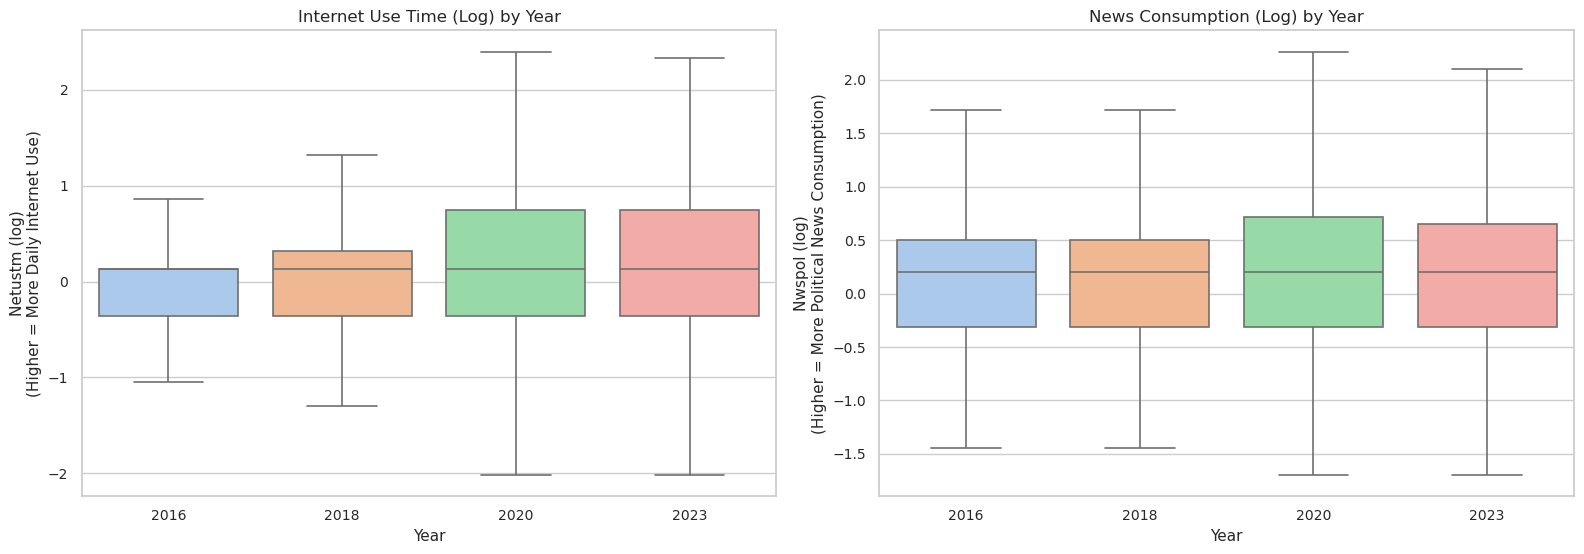

,variable,group,n,mean,med,q1,q3,whislo,whishi,fliers
0,netustm_log,2016,29822,-0.1154,0.1284,-0.3614,0.1284,-1.0445,0.8626,8838
1,netustm_log,2018,27630,-0.0828,0.1284,-0.3614,0.3150,-1.2984,1.3247,3435
2,netustm_log,2020,33882,0.0646,0.1284,-0.3614,0.7470,-2.0177,2.3993,933
3,netustm_log,2023,26418,0.0922,0.1284,-0.3614,0.7470,-2.0177,2.3342,347
4,nwspol_log,2016,29822,-0.0069,0.1985,-0.3147,0.5017,-1.4428,1.7151,2941
5,nwspol_log,2018,27630,-0.0319,0.1985,-0.3147,0.5017,-1.4428,1.7151,3226
6,nwspol_log,2020,33882,0.0602,0.1985,-0.3147,0.7177,-1.6979,2.2654,1749
7,nwspol_log,2023,26418,0.0250,0.1985,-0.3147,0.6523,-1.6979,2.1027,2418


In [13]:
figure1_data=pd.concat([box_summary(data,v,'Year') for v in ['netustm_log','nwspol_log']],ignore_index=True)
export_table(figure1_data,'figure_1_boxplot_data')
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,var,title,ylabel in zip(axes,['netustm_log','nwspol_log'],['Internet Use Time (Log) by Year','News Consumption (Log) by Year'],['Netustm (log)\n(Higher = More Daily Internet Use)','Nwspol (log)\n(Higher = More Political News Consumption)']):
    sns.boxplot(data=data,x='Year',y=var,hue='Year',legend=False,palette=sns.color_palette('pastel')[:4],linewidth=1.2,showfliers=False,ax=ax)
    ax.set(title=title,xlabel='Year',ylabel=ylabel)
fig.tight_layout(rect=[0,0,1,.95])
save_figure(fig,'figure_1_media_use')
display(figure1_data.round(4))

### Figure 2. Media Use & Immigration Attitudes by Country.

Article p.11. Published caption: “Slope label: β ± 1.96 SE (*, **, *** = p < .05/.01/.001).”

Source cell 53 uses both occupational groups, despite the manager-only description in the article. It sequentially retains the inclusive 5th–95th percentiles of internet, news, and then immigration attitudes, recomputing cutoffs at each step. All 36 panels are retained. Slopes are ordinary least-squares fits by country. The historical shaded band is `ŷ ±1.96 × SE(slope)` of constant width; it is not a conventional regression-mean confidence band. No trimming is applied to the main model sample.


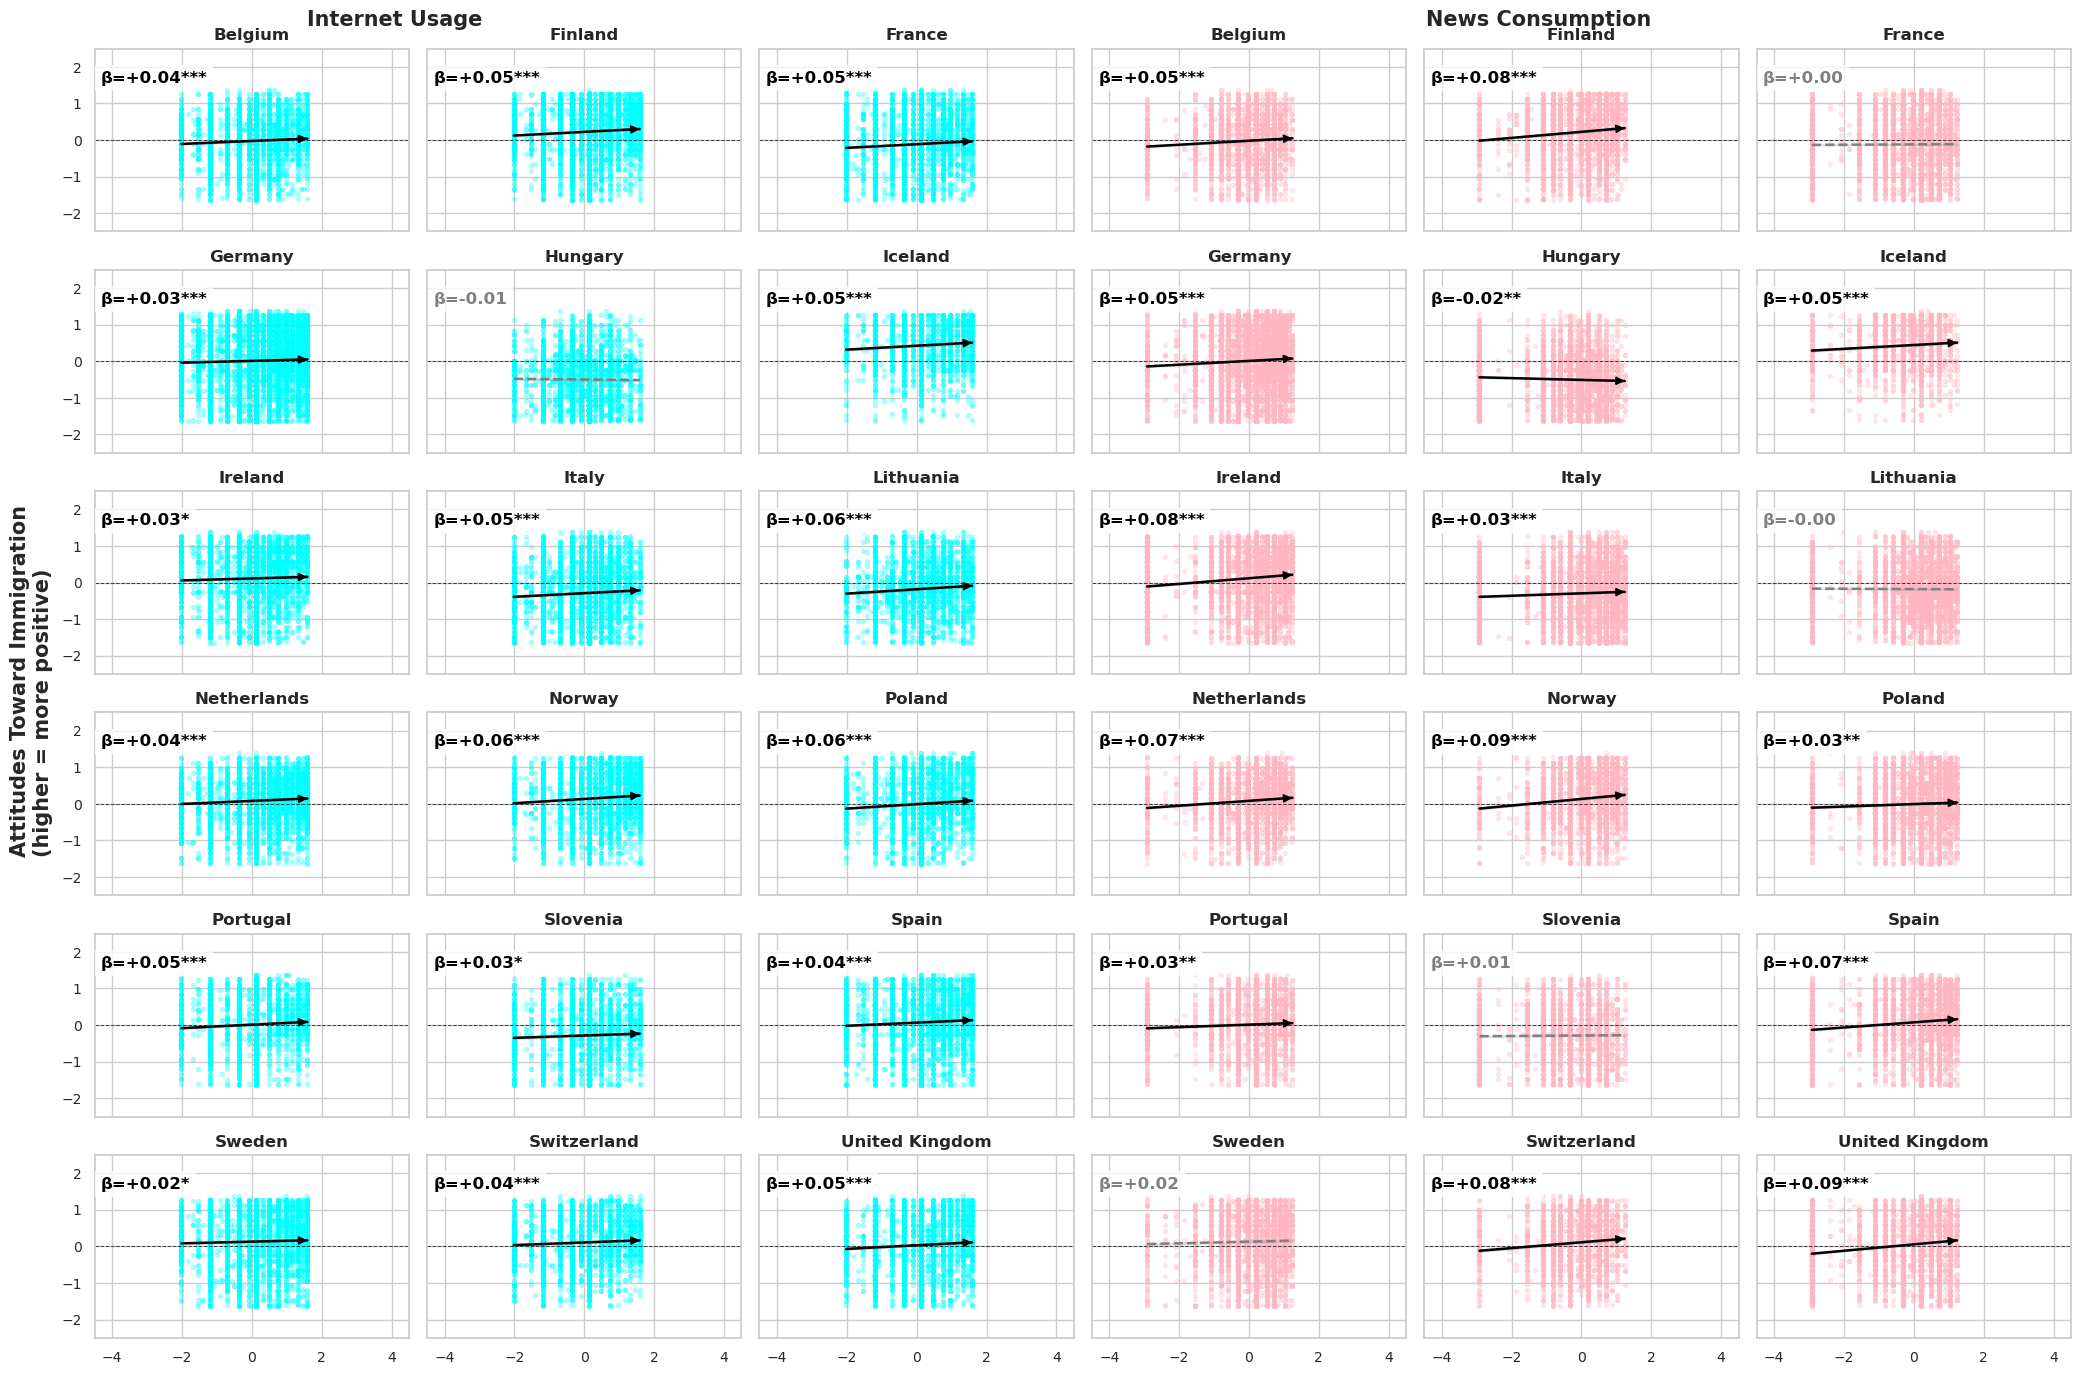

,Country,variable,n,intercept,slope,se,p,stars
0,Belgium,netustm_log,4569,-0.0255,0.0408,0.0108,0.0002,***
1,Belgium,nwspol_log,4569,-0.0196,0.0546,0.0113,0.0000,***
2,Finland,netustm_log,5766,0.2224,0.0498,0.0100,0.0000,***
3,Finland,nwspol_log,5766,0.2235,0.0827,0.0113,0.0000,***
4,France,netustm_log,5749,-0.1142,0.0500,0.0107,0.0000,***
5,France,nwspol_log,5749,-0.1193,0.0044,0.0103,0.6683,
6,Germany,netustm_log,11627,0.0117,0.0255,0.0073,0.0005,***
7,Germany,nwspol_log,11627,0.0106,0.0518,0.0091,0.0000,***
8,Hungary,netustm_log,5344,-0.4984,-0.0099,0.0131,0.4509,
9,Hungary,nwspol_log,5344,-0.5084,-0.0241,0.0079,0.0024,**


In [14]:
figure2_sample=data.copy()
trim_steps=[]
for variable in ['netustm_log','nwspol_log','attitudes_immigration']:
    lo,hi=figure2_sample[variable].quantile([.05,.95]);before=len(figure2_sample)
    figure2_sample=figure2_sample.loc[figure2_sample[variable].between(lo,hi)].copy()
    trim_steps.append({'variable':variable,'lower':lo,'upper':hi,'before':before,'after':len(figure2_sample)})
export_table(pd.DataFrame(trim_steps),'figure_2_sequential_trimming')
slopes=[];curves=[]
fig,axes=plt.subplots(6,6,figsize=(22,15.6),sharex=True,sharey=True)
left,right=axes[:,:3].ravel(),axes[:,3:].ravel()
for i,(country,d) in enumerate(figure2_sample.groupby('Country')):
    for variable,color,ax in [('netustm_log','cyan',left[i]),('nwspol_log','lightpink',right[i])]:
        fit=sm.OLS(d.attitudes_immigration,sm.add_constant(d[variable])).fit()
        beta,se,p=fit.params.iloc[1],fit.bse.iloc[1],fit.pvalues.iloc[1]
        slopes.append({'Country':country,'variable':variable,'n':len(d),'intercept':fit.params.iloc[0],'slope':beta,'se':se,'p':p,'stars':stars(p)})
        xgrid=np.linspace(d[variable].min(),d[variable].max(),150)
        yhat=fit.params.iloc[0]+beta*xgrid
        curves.append(pd.DataFrame({'Country':country,'variable':variable,'x':xgrid,'predicted':yhat,'band_low':yhat-1.96*se,'band_high':yhat+1.96*se}))
        sns.scatterplot(ax=ax,data=d,x=variable,y='attitudes_immigration',color=color,alpha=.35,edgecolor=None,s=12,rasterized=True)
        sig=p<.05
        ax.plot(xgrid,yhat,c='black' if sig else 'grey',lw=1.8,linestyle='-' if sig else '--')
        ax.fill_between(xgrid,yhat-1.96*se,yhat+1.96*se,color='grey',alpha=.25 if sig else .15)
        if sig:ax.annotate('',xy=(xgrid[-1],yhat[-1]),xytext=(xgrid[-6],yhat[-6]),arrowprops=dict(arrowstyle='-|>',color='black',lw=1.3))
        ax.text(.02,.88,f'β={beta:+.2f}{stars(p)}',transform=ax.transAxes,fontsize=12,fontweight='bold',va='top',ha='left',color='black' if sig else 'grey',bbox=dict(facecolor='white',alpha=.8,edgecolor='none'))
        ax.axhline(0,color='black',linestyle='--',linewidth=.7,alpha=.7)
        ax.set(xlim=(-4.5,4.5),ylim=(-2.5,2.5),xlabel='',ylabel='')
        ax.set_title(country,fontsize=12,weight='bold')
figure2_slopes=export_table(pd.DataFrame(slopes),'figure_2_slopes')
figure2_curves=export_table(pd.concat(curves,ignore_index=True),'figure_2_lines_and_bands')
fig.text(.23,.92,'Internet Usage',ha='center',fontsize=15,weight='bold')
fig.text(.75,.92,'News Consumption',ha='center',fontsize=15,weight='bold')
fig.text(.055,.5,'Attitudes Toward Immigration\n(higher = more positive)',va='center',rotation='vertical',fontsize=15,weight='bold')
fig.tight_layout(rect=[.07,.05,1,.93])
save_figure(fig,'figure_2_country_media')
display(figure2_slopes.round(4))

### Table 2. Multilevel Model Regression Results.

Article pp.12–13. The table below is extracted from the fitted objects. It preserves the published section and country order and reports computed signs and significance. It intentionally does not copy the publication’s inconsistent values or stars. All such differences are itemised in section 14.


In [15]:
table2_rows=[('Fixed Effect',None),('Intercept','Intercept'),('Sociodemographic Variables',None),('Age','age_category'),('Gender','gndr'),('Education','education_category'),('Income','hincfel'),('Political Orientation','lrscale'),('Religiosity','rlgdgr'),('Values',None),('Self-Transcendence','self_transcendence'),('Conservation','conservation'),('Media Consumption',None),('Internet Consumption','netustm_log'),('News Consumption','nwspol_log'),('European Manager','C(manager_flipped)[T.2]'),('Year Effects',None),('Y.2018','C(essround)[T.9]'),('Y.2020','C(essround)[T.10]'),('Y.2023','C(essround)[T.11]'),('Country Effects',None)]
table2_rows += [('Great Britain' if code=='GB' else name,f'C(cntry)[T.{code}]') for code,name in COUNTRIES.items() if code!='BE']
table2_rows += [('Random Effects',None),('Level 1: Residual','scale'),('Level 2: Country-Year','country_year Var'),('Level 3: Country Intercept','cntry Var'),('Level 3: Country × Internet Consumption Covariance','cntry x netustm_log Cov'),('Level 3: Internet Consumption Slope Variance','netustm_log Var'),('Level 3: Country × News Consumption Covariance','cntry x nwspol_log Cov'),('Level 3: Internet × News Consumption Covariance','netustm_log x nwspol_log Cov'),('Level 3: News Consumption Slope Variance','nwspol_log Var'),('Level 3: Year','essround Var'),('Model Fit (Deviance)','deviance')]
display_rows=[]; numeric_rows=[]
for label,term in table2_rows:
    row={'Variable':label}
    for n,result in fits.items():
        est=se=np.nan;sig=''
        if term=='scale':est=result.scale
        elif term=='deviance':est=-2*result.llf
        elif term in terms[n].index:
            est,se=terms[n].loc[term,['estimate','se']]
            sig=terms[n].loc[term,'stars']
        digits=2 if term=='deviance' else 4 if term=='netustm_log Var' else 3
        row[f'Model {n} Estimate']='' if term is None else '—' if pd.isna(est) else f'{est:.{digits}f}{sig}'
        row[f'Model {n} SE']='' if term is None else '—' if pd.isna(se) else f'{se:.3f}'
        if term is not None:numeric_rows.append({'row':label,'term':term,'model':n,'estimate':est,'se':se,'stars':sig,'digits':digits})
    display_rows.append(row)
table2=pd.DataFrame(display_rows)
table2_numeric=export_table(pd.DataFrame(numeric_rows),'table_2_numeric')
export_table(table2,'table_2_formatted')
show_table(table2,'Table 2. Multilevel Model Regression Results. Computed results; PDF differences are audited below.')
display(Markdown(f'*Models 1 and 2: N = {len(data):,}; {int(data.manager.eq(2).sum()):,} other workers and {len(managers):,} managers. Models 3 and 4: managers only, N = {len(managers):,}. Belgium is the country reference; ESS 8 (2016) is the year reference. European Manager is the positive manager-versus-worker coefficient. Stars: \\* p < .05, \\*\\* p < .01, \\*\\*\\* p < .001. No random-effect stars are assigned.*'))

Variable,Model 1 Estimate,Model 1 SE,Model 2 Estimate,Model 2 SE,Model 3 Estimate,Model 3 SE,Model 4 Estimate,Model 4 SE
Fixed Effect,,,,,,,,
Intercept,0.332***,0.034,0.332***,0.033,0.235**,0.089,0.212**,0.080
Sociodemographic Variables,,,,,,,,
Age,-0.022***,0.001,-0.023***,0.001,0.007,0.006,0.007,0.006
Gender,-0.004,0.005,-0.000,0.005,0.007,0.017,0.007,0.017
Education,0.108***,0.002,0.106***,0.002,0.103***,0.007,0.103***,0.007
Income,-0.145***,0.003,-0.143***,0.003,-0.150***,0.013,-0.149***,0.013
Political Orientation,-0.077***,0.001,-0.077***,0.001,-0.081***,0.004,-0.081***,0.004
Religiosity,0.011***,0.001,0.011***,0.001,0.002,0.003,0.002,0.003
Values,,,,,,,,


*Models 1 and 2: N = 117,752; 108,489 other workers and 9,263 managers. Models 3 and 4: managers only, N = 9,263. Belgium is the country reference; ESS 8 (2016) is the year reference. European Manager is the positive manager-versus-worker coefficient. Stars: \* p < .05, \*\* p < .01, \*\*\* p < .001. No random-effect stars are assigned.*

### Figure 3. Trends Analysis in Immigration Attitudes by Values and Media Use Among European Managers and Employees.

Article p.14; source cell 56. Group means of fixed-effect predictions from the separate trend model are plotted by year. Shading follows the historical `mean ±1.96 SD(predictions)/√N` calculation. Published event annotations provide context; they are not estimated event effects. The 2022 arrow points to an interpolation between survey-round points. “Neutral” denotes the displayed zero reference, not a validated neutral response category.


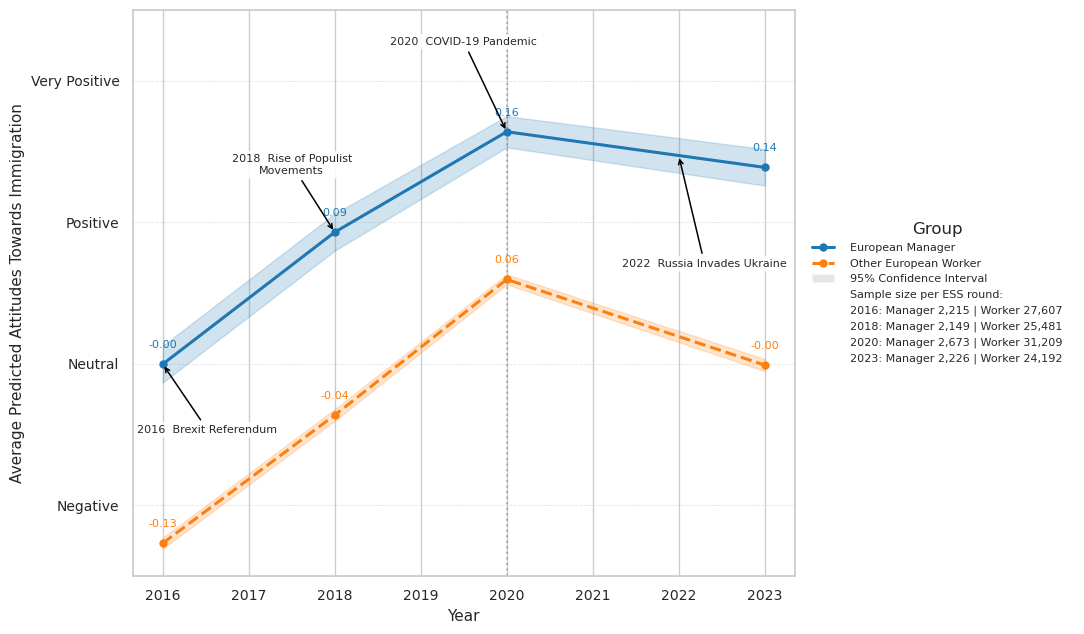

,Year,manager,mean,sd,n,se,ci_low,ci_high,Group
0,2016,1,-0.0002,0.3117,2215,0.0066,-0.0131,0.0128,European Manager
1,2016,2,-0.1266,0.3313,27607,0.0020,-0.1305,-0.1227,Other European Worker
2,2018,1,0.0930,0.3088,2149,0.0067,0.0800,0.1061,European Manager
3,2018,2,-0.0362,0.3365,25481,0.0021,-0.0403,-0.0320,Other European Worker
4,2020,1,0.1640,0.2905,2673,0.0056,0.1530,0.1750,European Manager
5,2020,2,0.0597,0.3166,31209,0.0018,0.0562,0.0632,Other European Worker
6,2023,1,0.1388,0.3098,2226,0.0066,0.1259,0.1517,European Manager
7,2023,2,-0.0008,0.3365,24192,0.0022,-0.0051,0.0034,Other European Worker


In [16]:
figure3_data=prediction_summary(data,trend_fit.predict(data),['Year','manager'])
figure3_data['Group']=figure3_data.manager.map(GROUPS)
export_table(figure3_data,'figure_3_predictions')
palette={'European Manager':'#1f77b4','Other European Worker':'#ff7f0e'}
fig,ax=plt.subplots(figsize=(11,6.5));handles=[]
for group,d in figure3_data.groupby('Group'):
    h,=ax.plot(d.Year,d['mean'],marker='o',ms=5,lw=2.2,linestyle='-' if group=='European Manager' else '--',color=palette[group],label=group,zorder=3)
    handles.append(h);ax.fill_between(d.Year,d.ci_low,d.ci_high,color=palette[group],alpha=.2,zorder=2)
for _,r in figure3_data.iterrows():ax.text(r.Year,r['mean']+.01,f"{r['mean']:.2f}",color=palette[r.Group],fontsize=8,ha='center',va='bottom')
ax.axvline(2020,linestyle=':',color='grey',alpha=.5)
ax.yaxis.grid(True,linestyle='--',linewidth=.6,alpha=.5)
ax.set(ylim=(-.15,.25),yticks=[-.1,0,.1,.2],yticklabels=['Negative','Neutral','Positive','Very Positive'],xlabel='Year',ylabel='Average Predicted Attitudes Towards Immigration')
legend=handles+[Patch(facecolor='grey',alpha=.2,label='95% Confidence Interval'),Patch(facecolor='none',edgecolor='none',label='Sample size per ESS round:')]
for year,d in figure3_data.groupby('Year'):
    counts=d.set_index('manager').n
    legend.append(Patch(facecolor='none',edgecolor='none',label=f'{year}: Manager {counts.loc[1]:,} | Worker {counts.loc[2]:,}'))
ax.legend(handles=legend,title='Group',frameon=False,loc='center left',bbox_to_anchor=(1,.5),handletextpad=1.5,borderpad=1,prop={'size':8})
manager_line=figure3_data.loc[figure3_data.manager.eq(1)].set_index('Year')['mean']
events=[(2016,'2016  Brexit Referendum',(.52,-.05)),(2018,'2018  Rise of Populist\nMovements',(-.5,.04)),(2020,'2020  COVID-19 Pandemic',(-.5,.06)),(2022,'2022  Russia Invades Ukraine',(.3,-.08))]
for year,text,shift in events:
    y=float(np.interp(year,manager_line.index,manager_line.values))
    ax.annotate(text,xy=(year,y),xytext=(year+shift[0],y+shift[1]),ha='center',va='bottom',fontsize=8,arrowprops=dict(arrowstyle='->',lw=1.1,color='black'),bbox=dict(boxstyle='round,pad=.25',fc='white',ec='none',alpha=.85))
fig.tight_layout();save_figure(fig,'figure_3_trends')
display(figure3_data.round(4))

### Figure 4. Interaction Effects of the Internet and News Consumption on Immigration Attitudes by Managerial Status in Europe.

Article p.14; source cell 59. The historical “Low / Medium Low / Medium High / High” categories come from `pd.qcut(q=4)` on the full analytical sample. Ties produce unequal group sizes. Predicted means are aggregated over each group’s observed covariates; this is not a fitted interaction test. Uncertainty follows the historical prediction-dispersion calculation. The published medium-low internet worker point lies below zero but its printed label omits the minus sign; computed labels below retain their signs.


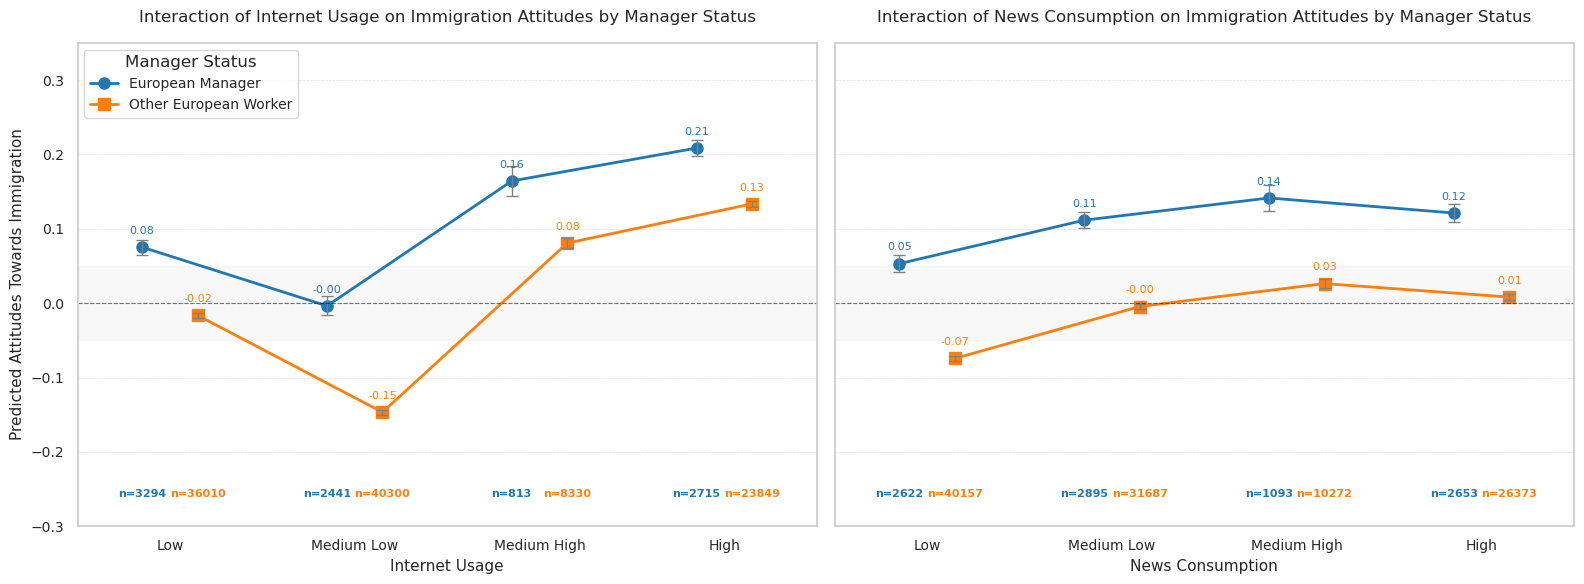

,Media,media_bin,manager,mean,sd,n,se,ci_low,ci_high,Group
0,internet,Low,1,0.0752,0.2979,3294,0.0052,0.0650,0.0854,European Manager
1,internet,Low,2,-0.0164,0.3091,36010,0.0016,-0.0196,-0.0132,Other European Worker
2,internet,Medium Low,1,-0.0038,0.3222,2441,0.0065,-0.0165,0.0090,European Manager
3,internet,Medium Low,2,-0.1467,0.3332,40300,0.0017,-0.1499,-0.1434,Other European Worker
4,internet,Medium High,1,0.1643,0.2892,813,0.0101,0.1444,0.1841,European Manager
5,internet,Medium High,2,0.0807,0.3049,8330,0.0033,0.0742,0.0872,Other European Worker
6,internet,High,1,0.2085,0.2818,2715,0.0054,0.1979,0.2191,European Manager
7,internet,High,2,0.1335,0.3105,23849,0.0020,0.1296,0.1375,Other European Worker
0,news,Low,1,0.0531,0.3098,2622,0.0061,0.0412,0.0650,European Manager
1,news,Low,2,-0.0743,0.3306,40157,0.0016,-0.0776,-0.0711,Other European Worker


In [17]:
bin_labels=['Low','Medium Low','Medium High','High']
predicted_media=media_fit.predict(data)
figure4_data={};bin_edges=[]
for media,var in [('internet','netustm_log'),('news','nwspol_log')]:
    cats,edges=pd.qcut(data[var],q=4,labels=bin_labels,retbins=True)
    for j in range(4):bin_edges.append({'media':media,'category':bin_labels[j],'lower':edges[j],'upper':edges[j+1]})
    summary=prediction_summary(data.assign(media_bin=cats),predicted_media,['media_bin','manager'])
    summary['Group']=summary.manager.map(GROUPS)
    figure4_data[media]=summary
    export_table(summary,f'figure_4_{media}_predictions')
export_table(pd.DataFrame(bin_edges),'figure_4_quartile_edges')
fig,axes=plt.subplots(1,2,figsize=(16,6),sharey=True)
for ax,media,title,xlabel in zip(axes,['internet','news'],['Interaction of Internet Usage on Immigration Attitudes by Manager Status','Interaction of News Consumption on Immigration Attitudes by Manager Status'],['Internet Usage','News Consumption']):
    summary=figure4_data[media]
    for manager,group in GROUPS.items():
        d=summary.loc[summary.manager.eq(manager)]
        offset=-.15 if manager==1 else .15;x=np.arange(4)+offset
        ax.plot(x,d['mean'],marker='o' if manager==1 else 's',markersize=8,linewidth=2,color=palette[group],label=group)
        ax.errorbar(x,d['mean'],yerr=1.96*d.se,fmt='none',capsize=4,color='gray',lw=1)
        for pos,(_,r) in zip(x,d.iterrows()):
            ax.text(pos,r['mean']+.015,f"{r['mean']:.2f}",ha='center',va='bottom',fontsize=8,color=palette[group])
            ax.text(pos,-.25,f'n={r.n}',ha='center',va='top',fontsize=8,weight='bold',color=palette[group],clip_on=False)
    ax.axhspan(-.05,.05,color='gray',alpha=.05);ax.axhline(0,linestyle='--',color='black',alpha=.5,linewidth=.8)
    ax.yaxis.grid(True,linestyle='--',linewidth=.5,alpha=.6)
    ax.set(xticks=np.arange(4),xticklabels=bin_labels,xlabel=xlabel,ylim=(-.3,.35),xlim=(-.5,3.5))
    ax.xaxis.grid(False)
    ax.set_title(title,pad=15)
axes[0].set_ylabel('Predicted Attitudes Towards Immigration')
axes[0].legend(title='Manager Status',loc='upper left')
fig.tight_layout();save_figure(fig,'figure_4_media_quartiles')
display(pd.concat(figure4_data,names=['Media']).reset_index(level=0).round(4))

### Figure 5. Country-Level Analysis of Immigration Attitudes by Values and Media Use Among European Managers and Workers.

Article p.16; source cell 62. All 18 countries appear, ordered by computed manager predicted mean. Bar darkness denotes whether the historical prediction-dispersion interval excludes zero; it does not test manager–worker differences. These are fixed-effect predictions averaged over observed covariates, without country random effects. The original 20-country draft caption has been replaced by the final publication caption.


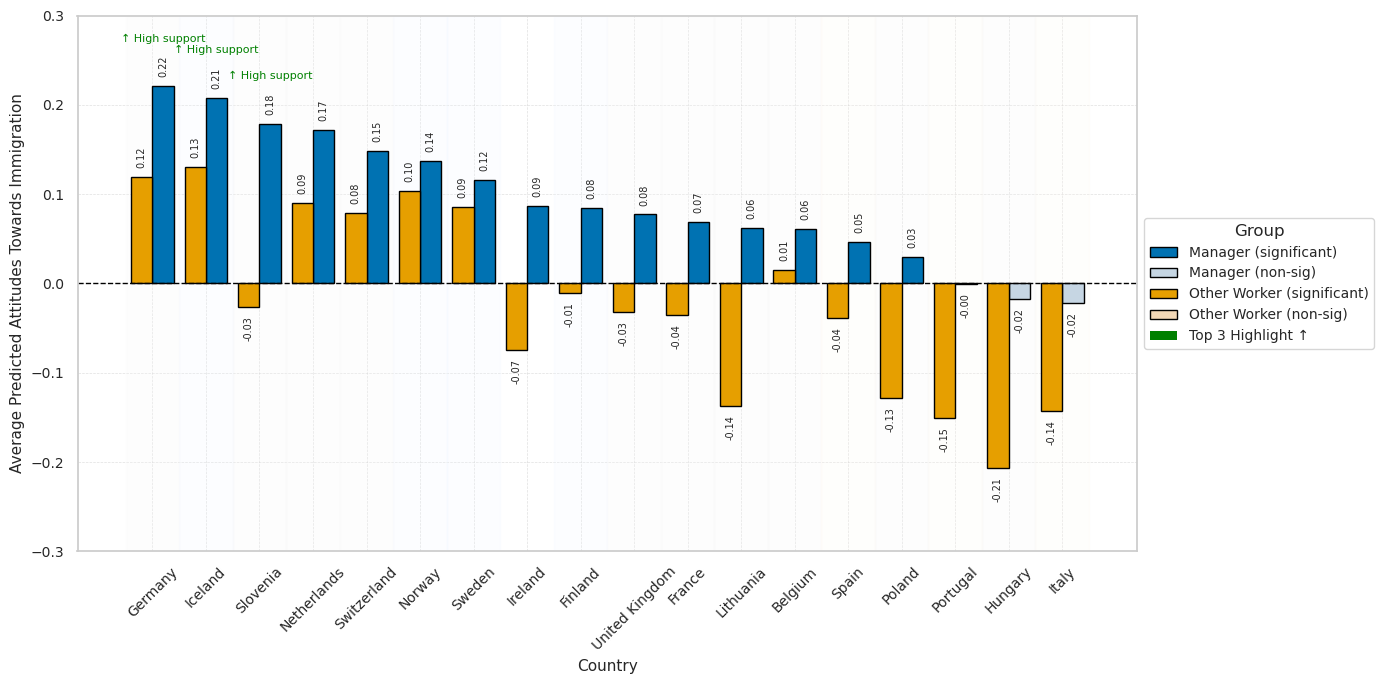

,cntry,manager,mean,sd,n,se,ci_low,ci_high,Country,Group,sig
0,BE,1,0.0606,0.3094,461,0.0144,0.0323,0.0888,Belgium,Manager,True
1,BE,2,0.0149,0.3218,5036,0.0045,0.0060,0.0238,Belgium,Other Worker,True
2,CH,1,0.1484,0.2928,478,0.0134,0.1222,0.1747,Switzerland,Manager,True
3,CH,2,0.0790,0.3145,3820,0.0051,0.0690,0.0890,Switzerland,Other Worker,True
4,DE,1,0.2208,0.2477,940,0.0081,0.2050,0.2367,Germany,Manager,True
5,DE,2,0.1192,0.2773,13626,0.0024,0.1145,0.1238,Germany,Other Worker,True
6,ES,1,0.0469,0.3487,477,0.0160,0.0156,0.0782,Spain,Manager,True
7,ES,2,-0.0390,0.3643,6293,0.0046,-0.0480,-0.0300,Spain,Other Worker,True
8,FI,1,0.0846,0.2757,328,0.0152,0.0547,0.1144,Finland,Manager,True
9,FI,2,-0.0112,0.3156,6190,0.0040,-0.0190,-0.0033,Finland,Other Worker,True


In [18]:
figure5_data=prediction_summary(data,predicted_media,['cntry','manager'])
figure5_data['Country']=figure5_data.cntry.map(COUNTRIES)
figure5_data['Group']=figure5_data.manager.map({1:'Manager',2:'Other Worker'})
figure5_data['sig']=~(figure5_data.ci_low.le(0)&figure5_data.ci_high.ge(0))
figure5_order=figure5_data.loc[figure5_data.manager.eq(1)].sort_values('mean',ascending=False).Country.tolist()
export_table(figure5_data,'figure_5_country_predictions')
fig,ax=plt.subplots(figsize=(14,7))
regions=[(['FI','SE','NO','IS'],'#f0f8ff'),(['DE','FR','BE','NL','CH','GB'],'#f9f9f9'),(['ES','IT','PT'],'#fefaf0'),(['PL','HU','LT','SI'],'#f5f5f5')]
for codes,color in regions:
    for code in codes:
        x=figure5_order.index(COUNTRIES[code]);ax.axvspan(x-.5,x+.5,color=color,alpha=.2)
colors={(1,True):'#0072B2',(1,False):'#c6d6e3',(2,True):'#E69F00',(2,False):'#f2d7b6'}
for _,r in figure5_data.iterrows():
    x=figure5_order.index(r.Country)+(.2 if r.manager==1 else -.2)
    ax.bar(x,r['mean'],width=.4,color=colors[(r.manager,r.sig)],edgecolor='black')
    positive=r['mean']>=0
    ax.text(x,r['mean']+(.01 if positive else -.01),f"{r['mean']:.2f}",ha='center',va='bottom' if positive else 'top',fontsize=7,rotation=90)
for _,r in figure5_data.loc[figure5_data.manager.eq(1)].nlargest(3,'mean').iterrows():
    ax.annotate('↑ High support',(figure5_order.index(r.Country)+.2,r['mean']+.05),ha='center',fontsize=8,color='green')
ax.axhline(0,color='black',linestyle='--',linewidth=1)
ax.set(xticks=np.arange(18),xticklabels=figure5_order,xlabel='Country',ylabel='Average Predicted Attitudes Towards Immigration',ylim=(-.3,.3))
plt.setp(ax.get_xticklabels(),rotation=45)
ax.grid(True,linestyle='--',linewidth=.5,alpha=.6)
legend=[Patch(facecolor=colors[(g,s)],edgecolor='black',label=f'{"Manager" if g==1 else "Other Worker"} ({"significant" if s else "non-sig"})') for g,s in [(1,True),(1,False),(2,True),(2,False)]]+[Patch(facecolor='green',edgecolor='none',label='Top 3 Highlight ↑')]
ax.legend(handles=legend,title='Group',loc='center left',bbox_to_anchor=(1,.5))
fig.tight_layout();save_figure(fig,'figure_5_country_attitudes')
display(figure5_data.round(4))

## 12. Supplementary Appendices 1–9

### Appendix 1. Country-wise Distribution of Managers and Other Workers Across ESS Rounds

In [19]:
rows=[]
for manager,group in [(1,'Manager'),(2,'Other Worker')]:
    sub=data.loc[data.manager.eq(manager)]
    for code,name in list(COUNTRIES.items())+[(None,'Total')]:
        d=sub if code is None else sub.loc[sub.cntry.eq(code)]
        rows.append({'Group':group,'Subgroup':name,**{f'ESS {r}':int(d.essround.eq(r).sum()) for r in YEARS},'All Rounds':len(d),'Percent of Group (%)':100*len(d)/len(sub)})
appendix1=export_table(pd.DataFrame(rows),'appendix_1_counts')
shown=appendix1.copy();shown['Percent of Group (%)']=shown['Percent of Group (%)'].map(lambda x:f'{x:.2f}'.rstrip('0').rstrip('.'))
show_table(shown,'Appendix 1. Country-wise Distribution of Managers and Other Workers Across ESS Rounds')

Group,Subgroup,ESS 8,ESS 9,ESS 10,ESS 11,All Rounds,Percent of Group (%)
Manager,Belgium,170,125,98,68,461,4.98
Manager,Switzerland,105,142,109,122,478,5.16
Manager,Germany,200,173,437,130,940,10.15
Manager,Spain,83,106,143,145,477,5.15
Manager,Finland,88,101,61,78,328,3.54
Manager,France,203,36,179,118,536,5.79
Manager,United Kingdom,155,195,129,180,659,7.11
Manager,Hungary,38,67,79,87,271,2.93
Manager,Ireland,225,162,62,208,657,7.09
Manager,Iceland,97,111,137,99,444,4.79


### Appendix 2. Sociodemographic Profile of European Managers and Employees in ESS Rounds 8–11

Percentages use the full analytical sample; all-round mean fields remain blank where the final PDF does not report them.

In [20]:
category_maps={
 'Age':('age_category',{1:'18 & under',2:'19-24',3:'25-34',4:'35-44',5:'45-54',6:'55-64',7:'65 & over'}),
 'Gender':('gndr',{1:'Male',2:'Female'}),
 'Manager Status':('manager',GROUPS),
 'Education Level':('education_category',{1:'Less than lower secondary',2:'Lower secondary completed',3:'Upper secondary completed',4:'Post-secondary non-tertiary completed',5:'Tertiary education completed'}),
 'Income Feeling':('hincfel',{1:'Living comfortably on present income',2:'Coping on present income',3:'Difficult on present income',4:'Very difficult on present income'})}
rows=[]
for variable,(col,cats) in category_maps.items():
    for code,label in cats.items():
        mask=data[col].eq(code)
        rows.append({'Variable':variable,'Category':label,**{f'ESS R{r}':int((mask&data.essround.eq(r)).sum()) for r in YEARS},'All Rounds':int(mask.sum()),'% of Total Sample':100*mask.mean()})
appendix2_counts=pd.DataFrame(rows)
appendix2_means=data.groupby('essround')[['lrscale','rlgdgr']].mean().T
for variable,col,label in [('Political Position','lrscale','Mean Political Position (0–10)'),('Religiosity','rlgdgr','Mean Religiosity (0–10)')]:
    rows.append({'Variable':variable,'Category':label,**{f'ESS R{r}':appendix2_means.loc[col,r] for r in YEARS},'All Rounds':np.nan,'% of Total Sample':np.nan})
appendix2=export_table(pd.DataFrame(rows),'appendix_2_profile')
shown=appendix2.copy()
for i in shown.index:
    for col in [f'ESS R{r}' for r in YEARS]+['All Rounds','% of Total Sample']:
        x=shown.at[i,col];digits=2 if i>=len(appendix2_counts) or col=='% of Total Sample' else 0
        shown[col]=shown[col].astype(object)
        shown.at[i,col]='' if pd.isna(x) else f'{x:.{digits}f}'
show_table(shown,'Appendix 2. Sociodemographic Profile of European Managers and Employees in ESS Rounds 8–11')

Variable,Category,ESS R8,ESS R9,ESS R10,ESS R11,All Rounds,% of Total Sample
Age,18 & under,1277,1061,1335,944,4617,3.92
Age,19-24,2158,1919,2425,1793,8295,7.04
Age,25-34,3847,3368,4081,3198,14494,12.31
Age,35-44,4431,3931,4569,3684,16615,14.11
Age,45-54,5167,4687,6036,4365,20255,17.20
Age,55-64,5249,4895,6023,4623,20790,17.66
Age,65 & over,7693,7769,9413,7811,32686,27.76
Gender,Male,14269,13032,15877,12568,55746,47.34
Gender,Female,15553,14598,18005,13850,62006,52.66
Manager Status,European Manager,2215,2149,2673,2226,9263,7.87


### Appendix 3. Outlier Aanalysis Report

The historical title’s spelling is preserved. All nonzero z-score outlier counts are shown; the full variable report is exported.

In [21]:
appendix3=outlier_table.loc[outlier_table['Outliers (count)'].gt(0)].copy()
export_table(appendix3,'appendix_3_outliers')
shown=appendix3.copy();shown['Outliers (%)']=shown['Outliers (%)'].map(lambda x:f'{x:.2f}')
show_table(shown,f'Appendix 3. Outlier Aanalysis Report (Rows with at least one outlier: {outlier_rows.sum()} / {len(data)} ({100*outlier_rows.mean():.2f}%))')

Variable,Outliers (count),Outliers (%)
ipeqopt,2359,2.00
impenv,2257,1.92
iphlppl,1637,1.39
netustm_log,965,0.82


### Appendix 4. Outlier Visualisation for Key Variables (~2% Outliers)

The four published horizontal boxplots use standardized item/log values. Fliers use the boxplot’s 1.5-IQR rule; Appendix 3 uses a different z-score rule.

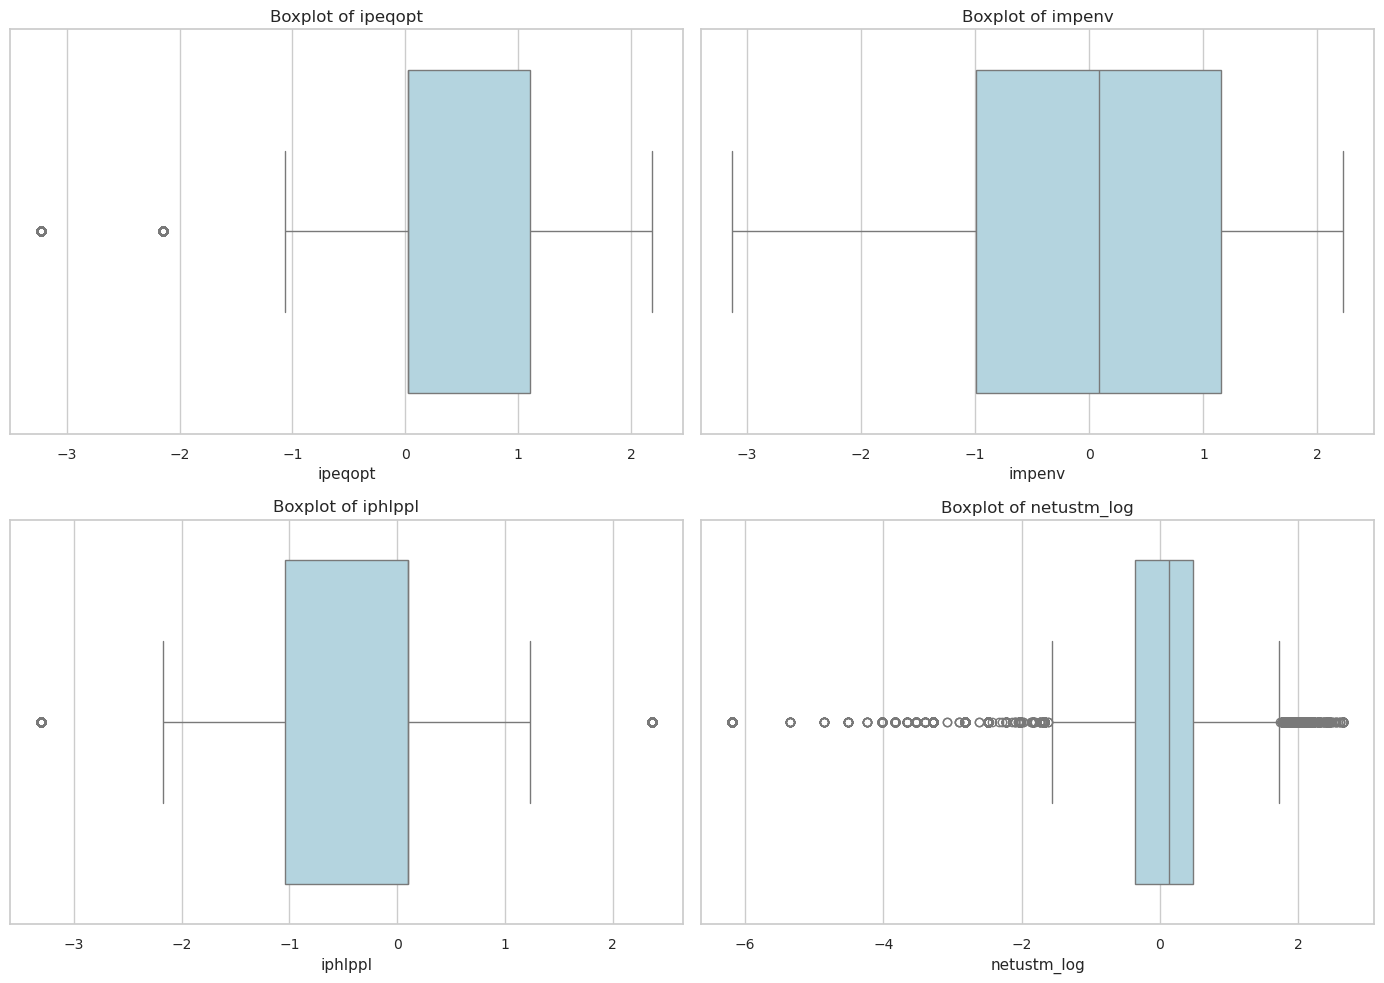

,variable,group,n,mean,med,q1,q3,whislo,whishi,fliers
0,ipeqopt,All,117752,-0.0145,0.0202,0.0202,1.1037,-1.0633,2.1872,8864
1,impenv,All,117752,-0.0092,0.0824,-0.9901,1.1548,-3.1349,2.2273,0
2,iphlppl,All,117752,-0.0160,0.0975,-1.0381,0.0975,-2.1737,1.2331,1931
3,netustm_log,All,117752,-0.0094,0.1284,-0.3614,0.4766,-1.5644,1.7220,9236


In [22]:
variables=['ipeqopt','impenv','iphlppl','netustm_log']
appendix4_data=pd.concat([box_summary(data,v) for v in variables],ignore_index=True)
export_table(appendix4_data,'appendix_4_boxplot_data')
fig,axes=plt.subplots(2,2,figsize=(14,10))
for ax,var in zip(axes.flat,variables):
    sns.boxplot(x=data[var],ax=ax,color='lightblue')
    ax.set_title(f'Boxplot of {var}',fontsize=12);ax.set_xlabel(var)
fig.tight_layout();save_figure(fig,'appendix_4_outliers')
display(appendix4_data.round(4))

### Appendix 5. Mean (SD) Attitudes Toward Immigration Among European Managers by Country and Year

The manager subset specified by the title is computed first. The separate historical full-sample computation follows, because that is what generated the published cells. Overall statistics pool respondents across all rounds, rather than averaging four yearly statistics.

In [23]:
def mean_sd_table(frame):
    rows=[]
    for country,d in frame.groupby('Country',sort=True):
        for year in list(YEARS.values())+['Overall']:
            x=d.attitudes_immigration if year=='Overall' else d.loc[d.Year.eq(year),'attitudes_immigration']
            rows.append({'Country':country,'Year':year,'mean':x.mean(),'sd':x.std(ddof=1),'n':len(x)})
    return pd.DataFrame(rows)

def mean_sd_display(frame):
    t=frame.copy(); t['Mean (SD)']=t.apply(lambda r:f"{str(round(r['mean'],2))} ({str(round(r['sd'],2))})",axis=1)
    return t.pivot(index='Country',columns='Year',values='Mean (SD)').reindex(columns=list(YEARS.values())+['Overall'])

appendix5_managers=export_table(mean_sd_table(managers),'appendix_5_managers_correctly_restricted')
appendix5_historical=export_table(mean_sd_table(data),'appendix_5_published_computation_full_sample')
show_table(mean_sd_display(appendix5_managers),'Appendix 5. Mean (SD) Attitudes Toward Immigration Among European Managers by Country and Year — computed manager subset',index=True)
display(Markdown('**Population discrepancy.** The published Appendix 5 values were generated without the manager filter (original cell 27). The following table reproduces that historical computation using both groups and is labelled accordingly. Neither table is populated from publication values. The outcome is the mean of three standardized items; it is not bounded to −1 to +1.'))
show_table(mean_sd_display(appendix5_historical),'Appendix 5 historical computation: full analytical sample',index=True)

Year,2016,2018,2020,2023,Overall
Country,,,,,
Belgium,-0.09 (0.75),-0.07 (0.72),0.17 (0.71),0.26 (0.67),0.02 (0.73)
Finland,0.4 (0.68),0.52 (0.64),0.76 (0.66),0.63 (0.63),0.56 (0.66)
France,-0.21 (0.85),-0.21 (0.92),0.08 (0.78),0.04 (0.85),-0.06 (0.84)
Germany,0.06 (0.83),0.13 (0.81),0.32 (0.83),0.14 (0.75),0.21 (0.82)
Hungary,-0.72 (0.8),-0.54 (0.8),-0.44 (0.78),-0.55 (1.02),-0.54 (0.87)
Iceland,0.64 (0.71),0.77 (0.74),0.82 (0.67),0.61 (0.8),0.72 (0.73)
Ireland,0.3 (0.83),0.41 (0.87),0.78 (0.83),0.45 (0.82),0.42 (0.85)
Italy,-0.62 (0.98),-0.42 (1.03),-0.17 (0.87),-0.39 (0.95),-0.38 (0.97)
Lithuania,-0.13 (0.82),-0.08 (0.79),-0.07 (0.83),-0.06 (0.76),-0.08 (0.8)


**Population discrepancy.** The published Appendix 5 values were generated without the manager filter (original cell 27). The following table reproduces that historical computation using both groups and is labelled accordingly. Neither table is populated from publication values. The outcome is the mean of three standardized items; it is not bounded to −1 to +1.

Year,2016,2018,2020,2023,Overall
Country,,,,,
Belgium,-0.16 (0.76),-0.08 (0.71),0.07 (0.7),0.0 (0.74),-0.05 (0.74)
Finland,0.15 (0.77),0.2 (0.76),0.34 (0.72),0.4 (0.74),0.26 (0.76)
France,-0.3 (0.91),-0.21 (0.88),-0.1 (0.88),-0.15 (0.89),-0.19 (0.89)
Germany,0.02 (0.85),0.08 (0.83),0.02 (0.91),0.02 (0.84),0.03 (0.88)
Hungary,-0.83 (0.83),-0.71 (0.79),-0.64 (0.79),-0.73 (0.9),-0.73 (0.83)
Iceland,0.58 (0.7),0.65 (0.71),0.69 (0.7),0.53 (0.76),0.62 (0.72)
Ireland,0.02 (0.91),0.16 (0.88),0.29 (0.86),0.09 (0.97),0.13 (0.91)
Italy,-0.68 (0.96),-0.52 (0.94),-0.29 (0.87),-0.38 (0.86),-0.47 (0.92)
Lithuania,-0.3 (0.77),-0.2 (0.85),-0.23 (0.89),-0.15 (0.82),-0.23 (0.83)


### Appendices 6–9. Model summaries

These summaries come directly from the four fitted objects. In Appendix 7, the positive manager coefficient uses other workers as reference. Appendix 8 includes the full random covariance matrix. Appendix 9 has 17 country contrasts relative to Belgium, representing all 18 countries. Printed PDF typos are retained only as validation expectations.

In [24]:
for n,fit in fits.items():
    display(Markdown(f'### Appendix {n+5}. Model {n} Summary'))
    print(fit.summary())
    print(f'Deviance: {-2*fit.llf:.14f}')
    display(Markdown('Formula: `'+fit.model.formula+'`'))
    if n==3:show_table(fit.cov_re,'Estimated random-effect covariance matrix',index=True)

### Appendix 6. Model 1 Summary

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: attitudes_immigration
No. Observations: 117752  Method:             REML                 
No. Groups:       72      Scale:              0.5956               
Min. group size:  729     Log-Likelihood:     -136806.4598         
Max. group size:  7831    Converged:          Yes                  
Mean group size:  1635.4                                           
--------------------------------------------------------------------
                    Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept            0.332     0.034    9.896  0.000   0.266   0.398
self_transcendence   0.183     0.004   41.076  0.000   0.174   0.191
conservation        -0.195     0.005  -43.109  0.000  -0.203  -0.186
netustm_log          0.014     0.002    5.968  0.000   0.010   0.019
nwspol_log           0.057     0.002   23.697  0.000   0

Formula: `attitudes_immigration ~ self_transcendence + conservation + netustm_log + nwspol_log + age_category + rlgdgr + gndr + education_category + hincfel + lrscale`

### Appendix 7. Model 2 Summary

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: attitudes_immigration
No. Observations: 117752  Method:             REML                 
No. Groups:       72      Scale:              0.5952               
Min. group size:  729     Log-Likelihood:     -136768.5138         
Max. group size:  7831    Converged:          Yes                  
Mean group size:  1635.4                                           
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                0.332    0.033   9.902 0.000  0.266  0.397
C(manager_flipped)[T.2]  0.079    0.009   9.143 0.000  0.062  0.096
self_transcendence       0.181    0.004  40.729 0.000  0.172  0.190
conservation            -0.194    0.005 -42.977 0.000 -0.203 -0.185
netustm_log              0.014    0.002   5.676 0.000  0.009  0

...

Formula: `attitudes_immigration ~ self_transcendence + conservation + netustm_log + nwspol_log + age_category + rlgdgr + gndr + education_category + hincfel + lrscale + C(essround)`

,cntry,netustm_log,nwspol_log
cntry,0.071806,0.004166,0.004047
netustm_log,0.004166,0.001119,0.000889
nwspol_log,0.004047,0.000889,0.000717


### Appendix 9. Model 4 Summary

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: attitudes_immigration
No. Observations: 9263    Method:             REML                 
No. Groups:       4       Scale:              0.5523               
Min. group size:  2149    Log-Likelihood:     -10468.2552          
Max. group size:  2673    Converged:          Yes                  
Mean group size:  2315.8                                           
--------------------------------------------------------------------
                    Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept            0.212     0.080    2.639  0.008   0.055   0.369
C(cntry)[T.CH]       0.189     0.049    3.871  0.000   0.093   0.285
C(cntry)[T.DE]       0.002     0.043    0.045  0.964  -0.082   0.086
C(cntry)[T.ES]       0.236     0.049    4.794  0.000   0.139   0.332
C(cntry)[T.FI]       0.522     0.054    9.626  0.000   0

Formula: `attitudes_immigration ~ self_transcendence + conservation + netustm_log + nwspol_log + age_category + rlgdgr + gndr + education_category + hincfel + lrscale + C(cntry)`

## 13. Reproducibility validation against the published article

**Expected values begin here.** The following object contains independently extracted or visually transcribed final-PDF reference values. It is used only by the tests below. Numeric counts use exact equality; displayed percentages, coefficients, means and SDs are compared at the reported precision. Full printed deviance precision is checked, with floating-point last-digit differences classified separately.

For Appendix 5, tests distinguish the reproduced full-sample computation from the incorrectly labelled manager population. Unprinted exact figure values cannot be independently validated from raster images and remain unresolved; matching visible labels does not establish equality of every unpublished coordinate.


In [25]:
EXPECTED = {'provenance': 'Transcribed/extracted from supplied final PDFs; validation only.', 'appendix1': [['Belgium', 170, 125, 98, 68, 461, 4.98], ['Switzerland', 105, 142, 109, 122, 478, 5.16], ['Germany', 200, 173, 437, 130, 940, 10.15], ['Spain', 83, 106, 143, 145, 477, 5.15], ['Finland', 88, 101, 61, 78, 328, 3.54], ['France', 203, 36, 179, 118, 536, 5.79], ['United Kingdom', 155, 195, 129, 180, 659, 7.11], ['Hungary', 38, 67, 79, 87, 271, 2.93], ['Ireland', 225, 162, 62, 208, 657, 7.09], ['Iceland', 97, 111, 137, 99, 444, 4.79], ['Italy', 67, 113, 99, 87, 366, 3.95], ['Lithuania', 97, 109, 182, 131, 519, 5.6], ['Netherlands', 144, 155, 130, 179, 608, 6.56], ['Norway', 150, 160, 113, 130, 553, 5.97], ['Poland', 199, 174, 268, 190, 831, 8.97], ['Portugal', 51, 43, 106, 79, 279, 3.01], ['Sweden', 87, 82, 259, 85, 513, 5.54], ['Slovenia', 56, 95, 82, 110, 343, 3.7], ['Total', 2215, 2149, 2673, 2226, 9263, 100.0], ['Belgium', 1337, 1364, 1024, 1311, 5036, 4.64], ['Switzerland', 999, 975, 977, 869, 3820, 3.52], ['Germany', 2355, 1883, 7394, 1994, 13626, 12.56], ['Spain', 1666, 1354, 1877, 1396, 6293, 5.8], ['Finland', 1760, 1570, 1459, 1401, 6190, 5.71], ['France', 1655, 1733, 1563, 1469, 6420, 5.92], ['United Kingdom', 1538, 1710, 870, 1218, 5336, 4.92], ['Hungary', 1550, 1575, 1743, 1979, 6847, 6.31], ['Ireland', 2080, 1661, 1367, 1481, 6589, 6.07], ['Iceland', 728, 683, 692, 630, 2733, 2.52], ['Italy', 2328, 2371, 2347, 2538, 9584, 8.83], ['Lithuania', 1970, 1670, 1424, 1186, 6250, 5.76], ['Netherlands', 1403, 1340, 1220, 1344, 5307, 4.89], ['Norway', 1225, 1097, 1150, 1042, 4514, 4.16], ['Poland', 1484, 1314, 1782, 1241, 5821, 5.37], ['Portugal', 1121, 881, 1533, 1100, 4635, 4.27], ['Sweden', 1281, 1232, 1746, 995, 5254, 4.84], ['Slovenia', 1127, 1068, 1041, 998, 4234, 3.9], ['Total', 27607, 25481, 31209, 24192, 108489, 100.0]], 'appendix2_counts': [[1277, 1061, 1335, 944, 4617, 3.92], [2158, 1919, 2425, 1793, 8295, 7.04], [3847, 3368, 4081, 3198, 14494, 12.31], [4431, 3931, 4569, 3684, 16615, 14.11], [5167, 4687, 6036, 4365, 20255, 17.2], [5249, 4895, 6023, 4623, 20790, 17.66], [7693, 7769, 9413, 7811, 32686, 27.76], [14269, 13032, 15877, 12568, 55746, 47.34], [15553, 14598, 18005, 13850, 62006, 52.66], [2215, 2149, 2673, 2226, 9263, 7.87], [27607, 25481, 31209, 24192, 108489, 92.13], [3106, 2646, 2341, 2021, 10114, 8.59], [4906, 4566, 5034, 4106, 18612, 15.81], [10982, 9824, 12327, 9521, 42654, 36.22], [1648, 1434, 2096, 1487, 6665, 5.66], [9180, 9160, 12084, 9283, 39707, 33.72], [10836, 10272, 13144, 10788, 45040, 38.25], [13890, 12719, 15779, 11913, 54301, 46.11], [3956, 3699, 3962, 3018, 14635, 12.43], [1140, 940, 997, 699, 3776, 3.21]], 'appendix2_means': [[5.13, 5.04, 4.95, 5.06], [4.56, 4.43, 4.1, 4.33]], 'appendix3': {'rows': 6564, 'percent': 5.57, 'ipeqopt': [2359, 2.0], 'impenv': [2257, 1.92], 'iphlppl': [1637, 1.39], 'netustm_log': [965, 0.82]}, 'appendix5': {'Belgium': [[-0.16, 0.76], [-0.08, 0.71], [0.07, 0.7], [0.0, 0.74], [-0.05, 0.74]], 'Finland': [[0.15, 0.77], [0.2, 0.76], [0.34, 0.72], [0.4, 0.74], [0.26, 0.76]], 'France': [[-0.3, 0.91], [-0.21, 0.88], [-0.1, 0.88], [-0.15, 0.89], [-0.19, 0.89]], 'Germany': [[0.02, 0.85], [0.08, 0.83], [0.02, 0.91], [0.02, 0.84], [0.03, 0.88]], 'Hungary': [[-0.83, 0.83], [-0.71, 0.79], [-0.64, 0.79], [-0.73, 0.9], [-0.73, 0.83]], 'Iceland': [[0.58, 0.7], [0.65, 0.71], [0.69, 0.7], [0.53, 0.76], [0.62, 0.72]], 'Ireland': [[0.02, 0.91], [0.16, 0.88], [0.29, 0.86], [0.09, 0.97], [0.13, 0.91]], 'Italy': [[-0.68, 0.96], [-0.52, 0.94], [-0.29, 0.87], [-0.38, 0.86], [-0.47, 0.92]], 'Lithuania': [[-0.3, 0.77], [-0.2, 0.85], [-0.23, 0.89], [-0.15, 0.82], [-0.23, 0.83]], 'Netherlands': [[-0.03, 0.66], [0.07, 0.61], [0.19, 0.61], [0.07, 0.65], [0.07, 0.64]], 'Norway': [[0.03, 0.75], [0.15, 0.75], [0.32, 0.71], [0.25, 0.72], [0.18, 0.74]], 'Poland': [[-0.1, 0.75], [0.02, 0.79], [0.23, 0.93], [-0.04, 0.78], [0.04, 0.83]], 'Portugal': [[0.0, 0.79], [0.16, 0.73], [0.09, 0.71], [-0.11, 0.73], [0.04, 0.74]], 'Slovenia': [[-0.54, 0.88], [-0.48, 0.9], [-0.32, 0.85], [-0.21, 0.87], [-0.39, 0.89]], 'Spain': [[-0.02, 0.84], [0.07, 0.85], [0.3, 0.95], [0.17, 0.85], [0.14, 0.89]], 'Sweden': [[0.27, 0.8], [0.3, 0.82], [-0.04, 0.99], [0.34, 0.77], [0.18, 0.88]], 'Switzerland': [[0.05, 0.73], [0.12, 0.68], [0.2, 0.68], [0.17, 0.71], [0.13, 0.7]], 'United Kingdom': [[-0.07, 0.9], [0.0, 0.95], [0.23, 0.92], [0.18, 0.95], [0.06, 0.94]]}, 'models': {'1': {'terms': {'Intercept': ['0.332', '0.034', '9.896', '0.000', '0.266', '0.398'], 'self_transcendence': ['0.183', '0.004', '41.076', '0.000', '0.174', '0.191'], 'conservation': ['-0.195', '0.005', '-43.109', '0.000', '-0.203', '-0.186'], 'netustm_log': ['0.014', '0.002', '5.968', '0.000', '0.010', '0.019'], 'nwspol_log': ['0.057', '0.002', '23.697', '0.000', '0.053', '0.062'], 'age_category': ['-0.022', '0.001', '-15.306', '0.000', '-0.024', '-0.019'], 'rlgdgr': ['0.011', '0.001', '14.111', '0.000', '0.010', '0.013'], 'gndr': ['-0.004', '0.005', '-0.948', '0.343', '-0.013', '0.005'], 'education_category': ['0.108', '0.002', '58.134', '0.000', '0.105', '0.112'], 'hincfel': ['-0.145', '0.003', '-44.983', '0.000', '-0.151', '-0.138'], 'lrscale': ['-0.077', '0.001', '-70.451', '0.000', '-0.079', '-0.075'], 'country_year Var': ['0.065', '0.014']}, 'scale': '0.5956', 'llf': '-136806.4598', 'deviance': '273612.9196406634', 'n': 117752, 'groups': 72, 'min_group': 729, 'max_group': 7831, 'mean_group': '1635.4'}, '2': {'terms': {'Intercept': ['0.332', '0.033', '9.902', '0.000', '0.266', '0.397'], 'C(manager_flipped)[T.2]': ['0.079', '0.009', '9.143', '0.000', '0.062', '0.096'], 'self_transcendence': ['0.181', '0.004', '40.729', '0.000', '0.172', '0.190'], 'conservation': ['-0.194', '0.005', '-42.977', '0.000', '-0.203', '-0.185'], 'netustm_log': ['0.014', '0.002', '5.676', '0.000', '0.009', '0.018'], 'nwspol_log': ['0.057', '0.002', '23.631', '0.000', '0.053', '0.062'], 'age_category': ['-0.023', '0.001', '-16.130', '0.000', '-0.026', '-0.020'], 'rlgdgr': ['0.011', '0.001', '14.156', '0.000', '0.010', '0.013'], 'gndr': ['-0.000', '0.005', '-0.090', '0.929', '-0.010', '0.009'], 'education_category': ['0.106', '0.002', '56.473', '0.000', '0.102', '0.110'], 'hincfel': ['-0.143', '0.003', '-44.247', '0.000', '-0.149', '-0.136'], 'lrscale': ['-0.077', '0.001', '-70.809', '0.000', '-0.079', '-0.075'], 'country_year Var': ['0.065', '0.014']}, 'scale': '0.5952', 'llf': '-136768.5138', 'deviance': '273537.0276087916', 'n': 117752, 'groups': 72, 'min_group': 729, 'max_group': 7831, 'mean_group': '1635.4'}, '3': {'terms': {'Intercept': ['0.235', '0.089', '2.628', '0.009', '0.060', '0.410'], 'C(essround)[T.9]': ['0.049', '0.023', '2.134', '0.003', '0.004', '0.093'], 'C(essround)[T.10]': ['0.179', '0.022', '8.121', '0.000', '0.136', '0.223'], 'C(essround)[T.11]': ['0.059', '0.023', '2.594', '0.009', '0.014', '0.104'], 'self_transcendence': ['0.214', '0.016', '13.558', '0.000', '0.183', '0.2245'], 'conservation': ['-0.217', '0.015', '-14.605', '0.000', '-0.246', '-0.188'], 'netustm_log': ['0.025', '0.011', '2.201', '0.028', '0.003', '0.048'], 'nwspol_log': ['0.0511', '0.012', '4.184', '0.000', '0.027', '0.075'], 'age_category': ['0.007', '0.006', '-1.062', '0.288', '-0.006', '-0.019'], 'rlgdgr': ['0.002', '0.003', '0.762', '0.446', '0.003', '0.007'], 'gndr': ['0.007', '0.017', '0.427', '0.669', '-0.026', '0.040'], 'education_category': ['0.103', '0.007', '14.453', '0.000', '0.089', '0.117'], 'hincfel': ['-0.150', '0.013', '-11.600', '0.000', '-0.175', '-0.125'], 'lrscale': ['-0.081', '0.004', '-21.961', '0.000', '-0.088', '-0.074'], 'cntry Var': ['0.072', '0.034'], 'cntry x netustm_log Cov': ['0.004', '0.005'], 'netustm_log Var': ['0.001', '0.001'], 'cntry x nwspol_log Cov': ['0.004', '0.005'], 'netustm_log x nwspol_log Cov': ['0.001', '0.001'], 'nwspol_log Var': ['0.001', '0.001']}, 'scale': '0.55509', 'llf': '-10469.3772', 'deviance': '20938.75437972734', 'n': 9263, 'groups': 18, 'min_group': 271, 'max_group': 940, 'mean_group': '514.6'}, '4': {'terms': {'Intercept': ['0.212', '0.080', '2.639', '0.008', '0.055', '0.369'], 'C(cntry)[T.CH]': ['0.189', '0.049', '3.871', '0.000', '0.093', '0.285'], 'C(cntry)[T.DE]': ['0.002', '0.043', '0.045', '0.964', '-0.082', '0.086'], 'C(cntry)[T.ES]': ['0.236', '0.049', '4.794', '0.000', '0.139', '0.332'], 'C(cntry)[T.FI]': ['0.522', '0.054', '9.626', '0.000', '0.415', '0.628'], 'C(cntry)[T.FR]': ['-0.091', '0.048', '-1.906', '0.057', '-0.184', '0.003'], 'C(cntry)[T.GB]': ['0.197', '0.045', '4.344', '0.000', '0.108', '0.286'], 'C(cntry)[T.HU]': ['-0.478', '0.057', '-8.327', '0.000', '-0.591', '-0.366'], 'C(cntry)[T.IE]': ['0.384', '0.046', '8.428', '0.000', '0.294', '0.473'], 'C(cntry)[T.IS]': ['0.546', '0.050', '10.869', '0.000', '0.447', '0.644'], 'C(cntry)[T.IT]': ['-0.308', '0.053', '-5.819', '0.000', '-0.412', '-0.204'], 'C(cntry)[T.LT]': ['-0.085', '0.049', '-1.735', '0.083', '-0.181', '0.011'], 'C(cntry)[T.NL]': ['0.023', '0.047', '0.489', '0.625', '-0.068', '0.114'], 'C(cntry)[T.NO]': ['0.167', '0.048', '3.513', '0.000', '0.074', '0.261'], 'C(cntry)[T.PL]': ['0.289', '0.044', '6.602', '0.000', '0.203', '0.375'], 'C(cntry)[T.PT]': ['0.251', '0.057', '4.377', '0.000', '0.139', '0.364'], 'C(cntry)[T.SE]': ['0.134', '0.049', '2.757', '0.006', '0.039', '0.230'], 'C(cntry)[T.SI]': ['-0.239', '0.054', '-4.454', '0.000', '-0.344', '-0.134'], 'self_transcendence': ['0.214', '0.016', '13.592', '0.000', '0.184', '0.245'], 'conservation': ['-0.216', '0.015', '-14.558', '0.000', '-0.245', '-0.187'], 'netustm_log': ['0.028', '0.008', '3.514', '0.000', '0.012', '0.044'], 'nwspol_log': ['0.053', '0.010', '5.288', '0.000', '0.034', '0.073'], 'age_category': ['0.007', '0.006', '1.085', '0.278', '-0.006', '0.019'], 'rlgdgr': ['0.002', '0.003', '0.738', '0.461', '-0.003', '0.007'], 'gndr': ['0.007', '0.017', '0.415', '0.678', '-0.026', '0.040'], 'education_category': ['0.103', '0.007', '14.419', '0.000', '-0.089', '0.117'], 'hincfel': ['-0.149', '0.013', '-11.508', '0.000', '-0.175', '-0.124'], 'lrscale': ['-0.081', '0.004', '-22.016', '0.000', '-0.088', '-0.074'], 'essround Var': ['0.006', '0.007']}, 'scale': '0.5523', 'llf': '-10468.2552', 'deviance': '20936.51034286384', 'n': 9263, 'groups': 4, 'min_group': 2149, 'max_group': 2673, 'mean_group': '2315.8'}}, 'table2': {'variables': ['<b>Fixed Effects</b>', 'Intercept', '<b>Sociodemographic Variables</b>', 'Age', 'Gender', 'Education', 'Income', 'Political Orientation', 'Religiosity', '<b>Values</b>', 'Self-Transcendence', 'Conservation', '<b>Media Consumption</b>', 'Internet Consumption', 'News Consumption', 'European Manager', '<b>Year Effects</b>', 'Y.2018', 'Y.2020', 'Y.2023', '<b>Country Effects</b>', 'C.Switzerland', 'C.Germany', 'C.Spain', 'C.Finland', 'C.France', 'C.Great Britain', 'C.Hungary', 'C.Ireland', 'C.Iceland', 'C.Italy', 'C.Lithuania', 'C.Netherlands', 'C.Norway', 'C.Poland', 'C.Portugal', 'C.Sweden', 'C.Slovenia', '<b>Random Effects</b>', 'Level 1: Residual', 'Level 2: Country-Year', 'Level 3: Country Intercept', 'Level 3: Country x Internet Consumption Covariance', 'Level 3: Internet Consumption Slope Variance', 'Level 3: Country x News Consumption Covariance', 'Level 3: Internet x News Consumption Covariance', 'Level 3: News Consumption Slope Variance', 'Level 3: Year', '<b>Model Fit (Deviance)</b>'], 'model_1_est': ['', '0.332***', '', '-0.022***', '-0.004', '0.108***', '-0.145***', '-0.077***', '0.011***', '', '0.183***', '-0.195***', '', '0.014***', '0.057***', '—', '', '—', '—', '—', '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', 0.596, 0.065, '—', '—', '—', '—', '—', '—', '—', 273612.92], 'model_1_se': ['', 0.034, '', 0.001, 0.005, 0.002, 0.003, 0.001, 0.001, '', 0.004, 0.005, '', 0.002, 0.002, '—', '', '—', '—', '—', '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', '', 0.014, '—', '—', '—', '—', '—', '—', '—', ''], 'model_2_est': ['', '0.332***', '', '-0.023***', '-0.000', '0.106***', '-0.143***', '-0.077***', '0.011***', '', '0.183***', '-0.195***', '', '0.014***', '0.057***', '-0.079***', '', '—', '—', '—', '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', 0.595, 0.065, '—', '—', '—', '—', '—', '—', '—', 273537.03], 'model_2_se': ['', 0.034, '', 0.001, 0.005, 0.002, 0.003, 0.001, 0.001, '', 0.004, 0.005, '', 0.002, 0.002, 0.009, '', '—', '—', '—', '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', '', 0.014, '—', '—', '—', '—', '—', '—', '—', ''], 'model_3_est': ['', '0.235***', '', '0.007', '0.007', '0.103***', '-0.150***', '-0.081***', '0.002***', '', '0.214***', '-0.217***', '', '0.025*', '0.051***', '—', '', '0.049***', '0.179***', '0.059***', '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', 0.551, '—', '0.072', '0.004', '0.0011', '0.004', '0.001', '0.001', '—', 20938.75], 'model_3_se': ['', 0.089, '', 0.006, 0.017, 0.007, 0.013, 0.004, 0.003, '', 0.016, 0.015, '', 0.011, 0.012, '—', '', 0.023, 0.022, 0.023, '', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '—', '', '', '—', 0.034, 0.005, 0.001, 0.005, 0.001, 0.001, '—', ''], 'model_4_est': ['', '0.212***', '', '0.007', '0.007', '0.103***', '-0.149***', '-0.081***', '0.002', '', '0.214***', '-0.216***', '', '0.028***', '0.053***', '—', '', '—', '—', '—', '', '0.189***', '0.002', '0.236***', '0.522***', '-0.091***', '0.197***', '-0.478***', '0.384***', '0.546***', '-0.308***', '-0.085*', '0.023**', '0.167***', '0.289***', '0.251***', '0.134***', '-0.239***', '', 0.552, '—', '—', '—', '—', '—', '—', '—', '0.006**', 20936.51], 'model_4_se': ['', 0.08, '', 0.006, 0.017, 0.007, 0.013, 0.004, 0.003, '', 0.016, 0.015, '', 0.008, 0.01, '—', '', '—', '—', '—', '', 0.049, 0.043, 0.049, 0.054, 0.048, 0.045, 0.057, 0.046, 0.05, 0.053, 0.049, 0.047, 0.048, 0.044, 0.057, 0.049, 0.054, '', '', '—', '—', '—', '—', '—', '—', '—', 0.007, '']}, 'fig3': {'1': [-0.0, 0.09, 0.16, 0.14], '2': [-0.13, -0.04, 0.06, -0.0]}, 'fig4': {'internet': {'1': [0.08, -0.0, 0.16, 0.21], '2': [-0.02, 0.15, 0.08, 0.13]}, 'news': {'1': [0.05, 0.11, 0.14, 0.12], '2': [-0.07, -0.0, 0.03, 0.01]}}, 'fig4_n': {'internet': {'1': [3294, 2441, 813, 2715], '2': [36010, 40300, 8330, 23849]}, 'news': {'1': [2622, 2895, 1093, 2653], '2': [40157, 31687, 10272, 26373]}}, 'fig5': {'order': ['Germany', 'Iceland', 'Slovenia', 'Netherlands', 'Switzerland', 'Norway', 'Sweden', 'Ireland', 'Finland', 'United Kingdom', 'France', 'Lithuania', 'Belgium', 'Spain', 'Poland', 'Portugal', 'Hungary', 'Italy'], '1': [0.22, 0.21, 0.18, 0.17, 0.15, 0.14, 0.12, 0.09, 0.08, 0.08, 0.07, 0.06, 0.06, 0.05, 0.03, -0.0, -0.02, -0.02], '2': [0.12, 0.13, -0.03, 0.09, 0.08, 0.1, 0.09, -0.07, -0.01, -0.03, -0.04, -0.14, 0.01, -0.04, -0.13, -0.15, -0.21, -0.14]}, 'fig2': {'countries': ['Belgium', 'Finland', 'France', 'Germany', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Lithuania', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom'], 'internet': [0.04, 0.05, 0.05, 0.03, -0.01, 0.05, 0.03, 0.05, 0.06, 0.04, 0.06, 0.06, 0.05, 0.03, 0.04, 0.02, 0.04, 0.05], 'news': [0.05, 0.08, 0.0, 0.05, -0.02, 0.05, 0.08, 0.03, -0.0, 0.07, 0.09, 0.03, 0.03, 0.01, 0.07, 0.02, 0.08, 0.09], 'internet_stars': ['***', '***', '***', '***', '', '***', '*', '***', '***', '***', '***', '***', '***', '*', '***', '*', '***', '***'], 'news_stars': ['***', '***', '', '***', '**', '***', '***', '***', '', '***', '***', '**', '**', '', '***', '', '***', '***']}}

In [26]:
# EXPECTED is embedded immediately before this cell. It is read only here, after
# every analytical table, fitted model, prediction and figure has been computed.
(OUT/'validation'/'publication_expected.json').write_text(json.dumps(EXPECTED,ensure_ascii=False,indent=2),encoding='utf-8')
checks=[]
def check(output,item,computed,published,digits=None,category='COMPUTATIONAL DISCREPANCY',source='',note=''):
    if digits is None:
        passed=computed==published
    else:
        passed=round(float(computed),digits)==round(float(published),digits)
    status='PASS' if bool(passed) else category
    checks.append({'output':output,'item':item,'computed':computed,'published':published,'decimals':digits,'status':status,'passed':bool(passed),'source':source,'explanation':note})

for item,value,target in [('raw rows',len(raw),131726),('raw columns',raw.shape[1],68),('exact duplicate rows',raw_integrity['duplicate_rows'],0),('duplicate respondent keys',raw_integrity['duplicate_respondent_keys'],0)]:
    check('Raw data',item,value,target,source='Supplied raw CSV inventory')
for item,value,target in [('analytic N',len(data),117752),('manager N',len(managers),9263),('other-worker N',int(data.manager.eq(2).sum()),108489),('countries',data.cntry.nunique(),18),('rounds',data.essround.nunique(),4),('country-year cells',data.country_year.nunique(),72)]:
    check('Sample',item,value,target,source='Article p.5; Appendix 1')
    assert value==target,(item,value,target)
for manager,counts in [(1,[2215,2149,2673,2226]),(2,[27607,25481,31209,24192])]:
    for r,target in zip(YEARS,counts):
        actual=int((data.manager.eq(manager)&data.essround.eq(r)).sum())
        check('Sample',f'{GROUPS[manager]} ESS {r}',actual,target,source='Appendix 1 totals')
        assert actual==target

for i,pub in enumerate(EXPECTED['appendix1']):
    row=appendix1.iloc[i]
    check('Appendix 1',f'row {i} country',row.Subgroup,pub[0],source='Appendix 1 p.1')
    for col,target in zip([f'ESS {r}' for r in YEARS]+['All Rounds','Percent of Group (%)'],pub[1:]):
        check('Appendix 1',f'{row.Group}/{row.Subgroup}/{col}',float(row[col]),target,2 if col.startswith('Percent') else None,source='Appendix 1 p.1')
        if not col.startswith('Percent'):assert int(row[col])==target
for i,pub in enumerate(EXPECTED['appendix2_counts']):
    row=appendix2_counts.iloc[i]
    for col,target in zip([f'ESS R{r}' for r in YEARS]+['All Rounds','% of Total Sample'],pub):
        check('Appendix 2',f'{row.Category}/{col}',float(row[col]),target,2 if col.startswith('%') else None,source='Appendix 2 p.2')
for i,col in enumerate(['lrscale','rlgdgr']):
    for r,target in zip(YEARS,EXPECTED['appendix2_means'][i]):check('Appendix 2',f'{col}/ESS {r}',appendix2_means.loc[col,r],target,2,source='Appendix 2 mean rows')
check('Appendix 3','rows with any outlier',int(outlier_rows.sum()),EXPECTED['appendix3']['rows'],source='Appendix 3 p.3')
check('Appendix 3','rows with any outlier (%)',100*outlier_rows.mean(),EXPECTED['appendix3']['percent'],2,source='Appendix 3 p.3')
for var,pub in EXPECTED['appendix3'].items():
    if var in ['rows','percent']:continue
    r=outlier_table.set_index('Variable').loc[var]
    for col,target,digits in [('Outliers (count)',pub[0],None),('Outliers (%)',pub[1],2)]:check('Appendix 3',var+'/'+col,r[col],target,digits,source='Appendix 3 p.3')
for name,frame in [('Appendix 5 historical full sample',appendix5_historical),('Appendix 5 labelled manager population',appendix5_managers)]:
    for country,expected in EXPECTED['appendix5'].items():
        for year,values in zip(list(YEARS.values())+['Overall'],expected):
            row=frame.loc[frame.Country.eq(country)&frame.Year.eq(year)].iloc[0]
            for col,target in zip(['mean','sd'],values):check(name,f'{country}/{year}/{col}',row[col],target,2,category='LABEL/REFERENCE-CATEGORY DIFFERENCE',source='Appendix 5 p.5',note='Published values match the full analytical sample; the caption incorrectly says managers.')

for n,fit in fits.items():
    pub=EXPECTED['models'][str(n)];source=f'Appendix {n+5} p.{n+5}'
    for term,values in pub['terms'].items():
        for col,target in zip(['estimate','se','z','p','ci_low','ci_high'],values):
            digits=len(target.split('.')[1])
            check(f'Model {n} / Appendix {n+5}',term+'/'+col,terms[n].loc[term,col],float(target),digits,category='PUBLICATION TYPOGRAPHICAL DISCREPANCY',source=source,note='Original stored model output and recomputation agree; compare estimate/SE and symmetric Wald interval.')
    sizes=[len(x) for x in fit.model.endog_li]
    stats={'n':int(fit.nobs),'groups':fit.model.n_groups,'scale':fit.scale,'llf':fit.llf,'min_group':min(sizes),'max_group':max(sizes),'mean_group':np.mean(sizes)}
    for key,value in stats.items():
        target=pub[key];digits=len(target.split('.')[1]) if isinstance(target,str) else None
        check(f'Model {n} / Appendix {n+5}',key,value,float(target) if digits is not None else target,digits,category='PUBLICATION TYPOGRAPHICAL DISCREPANCY',source=source)
    target=pub['deviance']
    check(f'Model {n} / Appendix {n+5}','deviance full printed precision',-2*fit.llf,float(target),len(target.split('.')[1]),category='ROUNDING ONLY',source=source,note='Binary floating-point/optimizer differences in final printed digits; full-precision comparison retained, no tolerance passed off as exact.')
    check(f'Model {n} / Appendix {n+5}','converged',bool(fit.converged),True,source=source)
    check(f'Model {n} / Appendix {n+5}','estimation','REML' if fit.reml else 'ML','REML',source=source)
    for term,row in terms[n].loc[terms[n].kind.eq('fixed')].iterrows():
        check('Internal model consistency',f'M{n} {term} p from normal z',float(2*norm.sf(abs(row['estimate']/row.se))),row.p,12,source='Independent Wald calculation')

pub=EXPECTED['table2']
assert len(pub['variables'])==len(table2_rows)
for i,(label,term) in enumerate(table2_rows):
    if term is None:continue
    for n in fits:
        actual=table2_numeric.loc[table2_numeric.row.eq(label)&table2_numeric.model.eq(n)].iloc[0]
        for field,key in [('estimate','est'),('se','se')]:
            target=pub[f'model_{n}_{key}'][i]
            if target in ['—','']:
                check('Table 2',f'M{n}/{label}/{field} absent',bool(pd.isna(actual[field])),True,source='Article pp.12–13')
                continue
            text=str(target);number=float(text.replace('*',''))
            digits=2 if term=='deviance' else 4 if term=='netustm_log Var' and field=='estimate' else 3
            check('Table 2',f'M{n}/{label}/{field}',actual[field],number,digits,category='LABEL/REFERENCE-CATEGORY DIFFERENCE' if term=='C(manager_flipped)[T.2]' else 'PUBLICATION TYPOGRAPHICAL DISCREPANCY',source='Article pp.12–13',note='Table is generated from fitted objects; discrepancies are not copied into computed results.')
            if field=='estimate' and term not in ['deviance','scale']:
                check('Table 2',f'M{n}/{label}/stars',actual.stars,'*'*text.count('*'),category='PUBLICATION TYPOGRAPHICAL DISCREPANCY',source='Article pp.12–13',note='Fixed-effect stars are calculated from fitted p values. Random-effect stars are omitted because no justified test is specified.')

for media,var in [('internet','netustm_log'),('news','nwspol_log')]:
    for i,country in enumerate(EXPECTED['fig2']['countries']):
        row=figure2_slopes.loc[figure2_slopes.Country.eq(country)&figure2_slopes.variable.eq(var)].iloc[0]
        check('Figure 2',f'{country}/{media}/slope',row.slope,EXPECTED['fig2'][media][i],2,source='Article p.11 visual label')
        check('Figure 2',f'{country}/{media}/stars',row.stars,EXPECTED['fig2'][media+'_stars'][i],source='Article p.11 visual label')
for manager in [1,2]:
    d=figure3_data.loc[figure3_data.manager.eq(manager)]
    for (_,row),target in zip(d.iterrows(),EXPECTED['fig3'][str(manager)]):check('Figure 3',f'{row.Year}/{GROUPS[manager]}/mean',row['mean'],target,2,source='Article p.14 visual point label')
for media in ['internet','news']:
    for manager in [1,2]:
        d=figure4_data[media].loc[figure4_data[media].manager.eq(manager)]
        for i,(_,row) in enumerate(d.iterrows()):
            check('Figure 4',f'{media}/{row.media_bin}/{GROUPS[manager]}/mean',row['mean'],EXPECTED['fig4'][media][str(manager)][i],2,category='PUBLICATION TYPOGRAPHICAL DISCREPANCY',source='Article p.14 visual point label',note='The PDF prints 0.15 at the negative medium-low worker point; computation gives -0.15. Position and original code confirm the omitted minus sign.')
            check('Figure 4',f'{media}/{row.media_bin}/{GROUPS[manager]}/n',int(row.n),EXPECTED['fig4_n'][media][str(manager)][i],source='Article p.14 sample-size annotation')
check('Figure 5','country order',figure5_order,EXPECTED['fig5']['order'],source='Article p.16')
for manager in [1,2]:
    for country,target in zip(EXPECTED['fig5']['order'],EXPECTED['fig5'][str(manager)]):
        row=figure5_data.loc[figure5_data.Country.eq(country)&figure5_data.manager.eq(manager)].iloc[0]
        check('Figure 5',f'{country}/{GROUPS[manager]}/mean',row['mean'],target,2,source='Article p.16 visual bar label')

# Prose checks cover the numerical regression statements, independently of Table 2.
prose=[(1,'self_transcendence','estimate',.183,3,11),(1,'conservation','estimate',-.195,3,11),(1,'nwspol_log','estimate',.057,3,11),(1,'netustm_log','estimate',.014,3,11),(1,'education_category','estimate',.108,3,11),(1,'rlgdgr','estimate',.011,3,11),(1,'lrscale','estimate',-.077,3,11),(1,'age_category','estimate',-.022,3,11),(1,'hincfel','estimate',-.145,3,11),(2,'self_transcendence','estimate',.181,3,14),(2,'conservation','estimate',-.194,3,14),(2,'nwspol_log','estimate',.057,3,14),(2,'netustm_log','estimate',.014,3,14),(3,'self_transcendence','estimate',.214,3,15),(3,'conservation','estimate',-.217,3,15),(3,'nwspol_log','estimate',.051,3,15),(3,'netustm_log','estimate',.025,3,15),(3,'netustm_log','p',.028,3,15),(3,'nwspol_log Var','estimate',.001,3,15),(3,'netustm_log Var','estimate',.0011,4,15),(4,'self_transcendence','estimate',.214,3,15),(4,'conservation','estimate',-.216,3,15),(4,'nwspol_log','estimate',.053,3,15),(4,'age_category','estimate',-.020,3,15),(4,'netustm_log','estimate',.028,3,15),(4,'netustm_log','p',.009,3,15)]
for n,term,col,target,digits,page in prose:check('Article prose',f'M{n}/{term}/{col}',terms[n].loc[term,col],target,digits,category='PUBLICATION TYPOGRAPHICAL DISCREPANCY',source=f'Article p.{page}')
for code,target in [('IS',.546),('IE',.384),('FI',.522),('PT',.251),('HU',-.478),('SI',-.239),('IT',-.308)]:check('Article prose',f'M4/country/{code}',terms[4].loc[f'C(cntry)[T.{code}]','estimate'],target,3,source='Article p.15')
check('Article prose','M2 other workers vs managers',-fits[2].fe_params['C(manager_flipped)[T.2]'],-.079,3,source='Article p.13',note='This prose contrast is the reverse of the fitted manager-versus-worker coefficient.')

# The PDFs do not provide exact numerical box statistics, scatter coordinates,
# ribbon endpoints, or unrounded predictions. These are not claimed verified.
for output,detail in [('Figure 1','Unlabelled exact quartiles and whiskers'),('Figure 2','Unprinted scatter coordinates and line-band endpoints'),('Figure 3','Unprinted interval endpoints'),('Figure 4','Unprinted interval endpoints'),('Figure 5','Unprinted interval endpoints and threshold decisions'),('Appendix 4','Unlabelled exact quartiles, whiskers and fliers')]:
    checks.append({'output':output,'item':detail,'computed':'Exported from raw-data computation','published':'No numeric reference in PDF','decimals':None,'status':'UNRESOLVED','passed':False,'source':'Published figure','explanation':'Printed labels are checked separately. Source code and visual layout are reproduced; exact unpublished plotting values cannot be independently validated from a raster image.'})

validation=pd.DataFrame(checks)
validation.to_csv(OUT/'validation'/'publication_validation.csv',index=False)
summary=validation.groupby(['output','status'],sort=False).size().unstack(fill_value=0)
display(summary)
failed=validation.loc[~validation.passed]
print(f'Publication/reference checks: {len(validation)}; passed: {int(validation.passed.sum())}; not passed: {len(failed)}.')
print('100% numerical reproduction is NOT claimed. Computed values and historical publication errors remain distinct.')
display(failed.loc[~failed.output.eq('Appendix 5 labelled manager population'),['output','item','computed','published','status']])

status,PASS,LABEL/REFERENCE-CATEGORY DIFFERENCE,ROUNDING ONLY,PUBLICATION TYPOGRAPHICAL DISCREPANCY,UNRESOLVED
output,,,,,
Raw data,4,0,0,0,0
Sample,14,0,0,0,0
Appendix 1,266,0,0,0,0
Appendix 2,128,0,0,0,0
Appendix 3,10,0,0,0,0
Appendix 5 historical full sample,180,0,0,0,0
Appendix 5 labelled manager population,5,175,0,0,0
Model 1 / Appendix 6,77,0,1,0,0
Internal model consistency,65,0,0,0,0


Publication/reference checks: 1894; passed: 1686; not passed: 208.
100% numerical reproduction is NOT claimed. Computed values and historical publication errors remain distinct.


,output,item,computed,published,status
857,Model 1 / Appendix 6,deviance full printed precision,273612.919641,273612.919641,ROUNDING ONLY
976,Model 3 / Appendix 8,C(essround)[T.9]/p,0.032804,0.003,PUBLICATION TYPOGRAPHICAL DISCREPANCY
996,Model 3 / Appendix 8,self_transcendence/ci_high,0.244904,0.2245,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1009,Model 3 / Appendix 8,nwspol_log/estimate,0.051221,0.0511,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1017,Model 3 / Appendix 8,age_category/z,1.061677,-1.062,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1020,Model 3 / Appendix 8,age_category/ci_high,0.019161,-0.019,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1025,Model 3 / Appendix 8,rlgdgr/ci_low,-0.003298,0.003,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1065,Model 3 / Appendix 8,scale,0.550929,0.55509,PUBLICATION TYPOGRAPHICAL DISCREPANCY
1070,Model 3 / Appendix 8,deviance full printed precision,20938.75438,20938.75438,ROUNDING ONLY
1241,Model 4 / Appendix 9,education_category/ci_low,0.088806,-0.089,PUBLICATION TYPOGRAPHICAL DISCREPANCY


## 14. Publication discrepancy audit

The following audit is also written to `REPRODUCIBILITY_AUDIT.md`. Every nonpassing numerical comparison is retained in `outputs/validation/publication_validation.csv`, with source, expected value, computed value, precision, and classification.

In [27]:
method_audit=[
('COMPUTATIONAL DISCREPANCY','Manager definition','Article p.5: ISCO 1000–1439',f"Original code uses all ISCO <=1439, including {classification_audit['manager_codes_below_1000']:,} below 1000; strict 1000–1439 count is {classification_audit['strict_1000_1439_managers']:,}.",'Historical classification retained for reproduction; occupations below 1000 are not silently relabelled as standard ISCO managers.'),
('COMPUTATIONAL DISCREPANCY','Value reversal','Article p.6: reversed according to ESS recommendations','Original cell 12 maps 1→5,2→4,3→3,4→2,5→1,6→6.','Literal historical rule retained. The highest original response becomes the highest coded value, so the orientation is not monotonic. A corrected scale would be a new analysis.'),
('COMPUTATIONAL DISCREPANCY','Scale construction','Article p.6: centered/averaged indexes then standardized','Each item is population-standardized over all raw rows before the sample restriction; composites are means of these z scores and are not standardized again.','No person-mean centering appears in source. Seven-item self-transcendence includes impfree,impdiff,ipcrtiv; preserve explicit item membership.'),
('COMPUTATIONAL DISCREPANCY','Robust standard errors','Article p.8 claims robust SEs','Original MixedLM.fit() uses model-based SEs; no robust covariance estimator is requested.','Model-based SEs reproduced. Do not describe them as robust.'),
('LABEL/REFERENCE-CATEGORY DIFFERENCE','Appendix 5 population','Appendix 5 and Article p.10 say managers','All published mean/SD cells come from the full analytical sample.','Both full-sample historical table and properly filtered manager table are computed and displayed; all differences are in the validation CSV.'),
('LABEL/REFERENCE-CATEGORY DIFFERENCE','Model 2 contrast','Table 2: European Manager -0.079; Appendix 7: +0.079','manager_flipped=2 is manager; reference 1 is other worker.','Computed table reports the positive manager-versus-worker coefficient. Negative prose contrast for other workers on p.13 is consistent after reversing the comparison.'),
('COMPUTATIONAL DISCREPANCY','Figure 2 population and trimming','Article p.10 says managers; p.7 says no outliers removed','Original Figure 2 uses both groups and sequential 5–95% trimming for internet, news, then outcome.','Main models retain all observations. Figure 2 alone uses the sequentially trimmed visualization sample.'),
('COMPUTATIONAL DISCREPANCY','Figure 2 shaded band','Original caption calls the shading a 95% confidence interval','Original cell 53 uses yhat ± 1.96 × slope SE at every x.','This constant-width band is not a standard regression-mean confidence band. Reproduced and explicitly identified; not silently replaced.'),
('LABEL/REFERENCE-CATEGORY DIFFERENCE','Figures 3–5 model identity','Original captions refer to Models 1/3','Figure 3 fits a separate full-sample ML country-intercept model with round fixed effects; Figures 4–5 share a separate full-sample REML country random-slope model.','The four article models and the two plotting fits are separately reported.'),
('COMPUTATIONAL DISCREPANCY','Figures 3–5 uncertainty and interaction language','Published captions describe confidence intervals / interaction effects','Fixed-effect predictions are averaged within observed groups; intervals are mean ±1.96 SD(predictions)/sqrt(N). Models have no managerial-status or product interaction term.','Bands quantify within-group dispersion of fitted predictions, not fitted-parameter uncertainty or a formal interaction test.'),
('LABEL/REFERENCE-CATEGORY DIFFERENCE','Figure 5 significance','Article p.16 discusses significant manager-worker differences','Bar darkness tests each prediction-average interval against zero; no between-group contrast is tested.','Do not interpret the shading as a manager-worker significance test. The displayed highest manager means are Germany, Iceland, Slovenia, not the prose country examples.'),
('LABEL/REFERENCE-CATEGORY DIFFERENCE','Zero and neutral','Figure 3 uses a Neutral label at zero','Zero is the pooled item-standardization reference, not the ESS response midpoint 5.','Published interpretive axis labels retained with this qualification.'),
('UNRESOLVED','Survey weighting and current employment','Article describes native-born workers','Source drops survey weights and does not filter current employment or working age. Birth country and occupation are imputed.','Reproduced unweighted estimand; supplied variables do not establish that every retained respondent is currently employed.'),
('UNRESOLVED','Optimizer boundary warnings','Source suppresses ConvergenceWarning', 'Final convergence is true for all six fits. Model 3 retries after initial optimizer failure; variance-boundary warnings remain for manager models and the full-sample random-slope fit.','Warnings are captured, displayed and exported; convergence does not remove variance-boundary cautions.'),
('UNRESOLVED','Unprinted figure values','Publication supplies raster figures without source plotting tables','Rounded point/slope/count labels are checked; exact unprinted values cannot be independently recovered.','All computed plotting summaries, curves and box statistics are exported; visual agreement does not prove equality of unpublished values.')]
methods=pd.DataFrame(method_audit,columns=['status','issue','published','computed','interpretation'])
methods.to_csv(OUT/'validation'/'methodological_discrepancies.csv',index=False)
show_table(methods,'Methodological and interpretive discrepancies')

def md_table(frame):
    def safe(x):return str(x).replace('|','/').replace('\n',' ')
    return '| '+' | '.join(map(safe,frame.columns))+' |\n| '+' | '.join(['---']*len(frame.columns))+' |\n'+'\n'.join('| '+' | '.join(safe(x) for x in r)+' |' for r in frame.itertuples(index=False,name=None))

report=f'''# Reproducibility audit

This workflow reconstructs the supplied original analysis from the raw ESS CSV. It does not reproduce every printed claim. Published discrepancies are preserved as validation expectations; they never generate analytical results.

## Scope and source review

The forensic review covered all 65 original notebook cells and stored outputs, all 25 article pages, all nine supplementary pages, and the raw data. `PUBLICATION_OUTPUT_MANIFEST.json` records all 16 numbered outputs. Main figures, the appendix boxplots, and model/table pages were rendered for visual inspection. Original files were not edited.

## Computed sample and execution

Raw: {len(raw):,} rows × {raw.shape[1]} columns. Analytical: {len(data):,}; managers: {len(managers):,}; other workers: {int(data.manager.eq(2).sum()):,}; countries: {data.cntry.nunique()}; rounds: {data.essround.nunique()}; country-year cells: {data.country_year.nunique()}.

SHA-256: `{raw_hash}`. Raw bytes: {RAW_PATH.stat().st_size:,}. No duplicate respondent keys. Outlier union: {int(outlier_rows.sum()):,} ({100*outlier_rows.mean():.2f}%).

All four main models and both plotting fits report final convergence. Full diagnostics and warnings are in `outputs/tables/model_diagnostics.csv`. Execution of this audit cell means prior analytical cells completed in this kernel; independent clean-run confirmation is recorded in `EXECUTION_CHECK.json` after the external execution harness finishes.

## Validation totals

{len(validation)} checks; {int(validation.passed.sum())} PASS; {len(failed)} not passed. Of the latter, {int(failed.status.eq('ROUNDING ONLY').sum())} are final-digit floating-point differences and {int(failed.status.eq('UNRESOLVED').sum())} concern unavailable numerical figure references. These counts include separate checks of the incorrectly labelled Appendix 5 manager population; the historical full-sample table is checked separately. Internal Wald consistency checks are identified as internal, not publication evidence.

{md_table(summary.reset_index())}

## Methodological discrepancies

{md_table(methods)}

## Numerical and notation discrepancies

Every nonpassing numerical comparison follows, including the manager-only Appendix 5 cells. Values are unrounded computed results; the decimals column specifies the publication precision. `ROUNDING ONLY` is not promoted to exact agreement.

{md_table(failed[['output','item','computed','published','decimals','status','source']])}

## Reproduction decision

The notebook provides an executable reproduction of the original computation, with publication errors and unresolved interpretations documented. It cannot truthfully be described as 100% reproduction of all final published numbers, labels, and interpretations. No published numeric value is used to generate a fitted model, data-derived table, point, slope, count, or band.

The sample and Appendix 1–3 anchors, historical Appendix 5 full-sample values, fitted model estimates, and labelled figure values are assessed independently in the validation file. Models retain the historical scale coding, unweighted analysis, pooled imputation, and ordinal numeric demographic covariates. The corrected manager-only Appendix 5 table is an explicitly separate view, not a silent alteration of the historical result.

## Data access and archiving

The article p.21 identifies the European Social Survey portal: https://ess.sikt.no/en/. Place the named raw CSV beside the notebook. No cleaned CSV, PDF, original notebook, network connection, or helper script is required to run the final notebook. The archive excludes respondent-level CSV data. Applicable ESS redistribution terms have not been adjudicated here; do not infer data permission from the article or code licence.

## Environment

Python {platform.python_version()}; {platform.platform()}. Package versions used in this run are pinned in `requirements.txt`. Historical code was originally run with statsmodels 0.14.2; the successful reproduction preserves its default fitting sequence.

{md_table(pd.DataFrame(list(VERSIONS.items()),columns=['Package','Version']))}
'''
(ROOT/'REPRODUCIBILITY_AUDIT.md').write_text(report,encoding='utf-8')
(OUT/'validation'/'validation_totals.json').write_text(json.dumps({'checks':len(validation),'passed':int(validation.passed.sum()),'not_passed':len(failed),'statuses':validation.status.value_counts().to_dict(),'publication_checks':int(validation.output.ne('Internal model consistency').sum())},indent=2),encoding='utf-8')

status,issue,published,computed,interpretation
COMPUTATIONAL DISCREPANCY,Manager definition,Article p.5: ISCO 1000–1439,"Original code uses all ISCO <=1439, including 355 below 1000; strict 1000–1439 count is 8,908.",Historical classification retained for reproduction; occupations below 1000 are not silently relabelled as standard ISCO managers.
COMPUTATIONAL DISCREPANCY,Value reversal,Article p.6: reversed according to ESS recommendations,"Original cell 12 maps 1→5,2→4,3→3,4→2,5→1,6→6.","Literal historical rule retained. The highest original response becomes the highest coded value, so the orientation is not monotonic. A corrected scale would be a new analysis."
COMPUTATIONAL DISCREPANCY,Scale construction,Article p.6: centered/averaged indexes then standardized,Each item is population-standardized over all raw rows before the sample restriction; composites are means of these z scores and are not standardized again.,"No person-mean centering appears in source. Seven-item self-transcendence includes impfree,impdiff,ipcrtiv; preserve explicit item membership."
COMPUTATIONAL DISCREPANCY,Robust standard errors,Article p.8 claims robust SEs,Original MixedLM.fit() uses model-based SEs; no robust covariance estimator is requested.,Model-based SEs reproduced. Do not describe them as robust.
LABEL/REFERENCE-CATEGORY DIFFERENCE,Appendix 5 population,Appendix 5 and Article p.10 say managers,All published mean/SD cells come from the full analytical sample.,Both full-sample historical table and properly filtered manager table are computed and displayed; all differences are in the validation CSV.
LABEL/REFERENCE-CATEGORY DIFFERENCE,Model 2 contrast,Table 2: European Manager -0.079; Appendix 7: +0.079,manager_flipped=2 is manager; reference 1 is other worker.,Computed table reports the positive manager-versus-worker coefficient. Negative prose contrast for other workers on p.13 is consistent after reversing the comparison.
COMPUTATIONAL DISCREPANCY,Figure 2 population and trimming,Article p.10 says managers; p.7 says no outliers removed,"Original Figure 2 uses both groups and sequential 5–95% trimming for internet, news, then outcome.",Main models retain all observations. Figure 2 alone uses the sequentially trimmed visualization sample.
COMPUTATIONAL DISCREPANCY,Figure 2 shaded band,Original caption calls the shading a 95% confidence interval,Original cell 53 uses yhat ± 1.96 × slope SE at every x.,This constant-width band is not a standard regression-mean confidence band. Reproduced and explicitly identified; not silently replaced.
LABEL/REFERENCE-CATEGORY DIFFERENCE,Figures 3–5 model identity,Original captions refer to Models 1/3,Figure 3 fits a separate full-sample ML country-intercept model with round fixed effects; Figures 4–5 share a separate full-sample REML country random-slope model.,The four article models and the two plotting fits are separately reported.
COMPUTATIONAL DISCREPANCY,Figures 3–5 uncertainty and interaction language,Published captions describe confidence intervals / interaction effects,Fixed-effect predictions are averaged within observed groups; intervals are mean ±1.96 SD(predictions)/sqrt(N). Models have no managerial-status or product interaction term.,"Bands quantify within-group dispersion of fitted predictions, not fitted-parameter uncertainty or a formal interaction test."


269

## 15. Session information and raw-data recheck

The raw checksum is checked again. Requirements are pinned to the packages actually used by this kernel.

In [28]:
session={'python':platform.python_version(),'platform':platform.platform(),'packages':VERSIONS,'raw_sha256_after':hashlib.sha256(RAW_PATH.read_bytes()).hexdigest(),'random_seed':964,'blas_threads_for_models':1}
assert session['raw_sha256_after']==raw_hash,'Raw input changed during execution'
print(json.dumps(session,indent=2))
(OUT/'validation'/'session.json').write_text(json.dumps(session,indent=2),encoding='utf-8')
(ROOT/'requirements.txt').write_text('\n'.join(f'{p}=={v}' for p,v in VERSIONS.items())+'\n',encoding='utf-8')

{
  "python": "3.11.9",
  "platform": "Windows-10-10.0.26300-SP0",
  "packages": {
    "pandas": "2.2.3",
    "numpy": "1.26.4",
    "scipy": "1.13.1",
    "statsmodels": "0.14.2",
    "scikit-learn": "1.4.2",
    "matplotlib": "3.8.4",
    "seaborn": "0.13.2",
    "nbformat": "5.9.2",
    "nbclient": "0.8.0",
    "ipykernel": "6.28.0",
    "patsy": "0.5.6",
    "threadpoolctl": "2.2.0"
  },
  "raw_sha256_after": "3ffcd57ddc096167f608e5ef53beaa9812ae7f18105001f36050484261715a01",
  "random_seed": 964,
  "blas_threads_for_models": 1
}


200